In [1]:
import sys
from scipy.stats import sem
sys.path.append(r'/Users/michaelfinch/CA1-interneuron-GLM/')

from utils_TCA_clustering_scratchpad import *
from GLM_regression_plotting import *


from modelling_to_date_utils import *

from modelling_multiple_generative_cells_utils import *

from utils_TCA_clustering_scratchpad import get_elbow_score_data 

/Users/michaelfinch/CA1-interneuron-GLM/utils.py:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
# activity_dict, predicted_activity_dict_NDNF_new, filtered_factors_dict, new_NDNF_activity_dict, new_NDNF_velocity_dict, residual_activity_dict_NDNF_new = load_data_regular(name="NDNFanalC", new_NDNF=True)
# # activity_dict, filtered_factors_dict, double_new_NDNF_activity_dict_100, double_new_NDNF_velocity_dict_100, double_residual_activity_dict_NDNF_new_100 = load_data_double(name="NDNFanalC", double_track=True)

# GLM_params, activity_dict, double_predicted_activity_dict_NDNF_new, factors_dict, filtered_factors_dict, residual_activity_dict_NDNF_new = load_data_regular(name="NDNFanalC", new_NDNF=True)
# GLM_params_old_NDNF, activity_dict_old_NDNF, double_predicted_activity_dict_NDNF_old, factors_dict_old_NDNF, filtered_factors_dict_old_NDNF, residual_activity_dict_NDNF_old = load_data_regular(name="NDNFindivsomata_GLM", new_NDNF=False)
GLM_params_SST, activity_dict_SST, double_predicted_activity_dict_SST, factors_dict_SST, filtered_factors_dict_SST, residual_activity_dict_SST = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="SSTindivsomata_GLM", new_NDNF=False)
GLM_params_EC, activity_dict_EC, double_predicted_activity_dict_EC, factors_dict_EC, filtered_factors_dict_EC, residual_activity_dict_EC = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="EC_GLM", new_NDNF=False)


GLM_params_NDNF_newest, activity_dict_NDNF_newest, double_predicted_activity_dict_NDNF_newest, factors_dict_NDNF_newest, filtered_factors_dict_NDNF_newest, residual_activity_dict_NDNF_newest = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="NDNF_E1A1B", new_NDNF=True)


fixed_residual_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(residual_activity_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_residual_activity_dict_NDNF_newest[f"animal_{idx+1}"] = residual_activity_dict_NDNF_newest[animal]

fixed_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(activity_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_activity_dict_NDNF_newest[f"animal_{idx+1}"] = activity_dict_NDNF_newest[animal]



In [3]:
fixed_filtered_factors_dict_NDNF_newest = {}
for idx, animal in enumerate(filtered_factors_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_filtered_factors_dict_NDNF_newest[f"animal_{idx+1}"] = filtered_factors_dict_NDNF_newest[animal]


In [4]:
means_list_EC = get_means_list(residual_activity_dict_EC)
means_list_SST = get_means_list(residual_activity_dict_SST)
means_list_NDNF = get_means_list(residual_activity_dict_NDNF_newest)

In [8]:
pwd

'/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date'

In [5]:
############# data loading -- contiguous cell 

base="/Users/michaelfinch/CA1-interneuron-GLM/datasets/"
mse_dir = f"{base}cell_SST_model_ranks20_contig_x00_cells"
cell_SST_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

mse_dir = f"{base}cell_EC_model_ranks20_contig_x00_cells"
cell_EC_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

mse_dir = f"{base}real_final_NDNF_model_ranks20_contig_x00_cell"
cell_NDNF_model_ranks20_contig_x00_cue = get_model_data_per_cell(mse_dir)

    
fixed_cell_NDNF_model_ranks20_contig_x00_cue = {20: {}}
for idx, animal in enumerate(cell_NDNF_model_ranks20_contig_x00_cue[20]):
    if 17<idx<31:
        fixed_cell_NDNF_model_ranks20_contig_x00_cue[20][animal-18] = cell_NDNF_model_ranks20_contig_x00_cue[20][animal]
        
    
    

Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 5 cells
    Animal 1: 15 cells
    Animal 2: 6 cells
    Animal 3: 4 cells
    Animal 4: 13 cells
    Animal 5: 13 cells
    Animal 6: 3 cells
    Animal 7: 3 cells
    Animal 8: 3 cells
    Animal 9: 10 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 192 cells
    Animal 1: 150 cells
    Animal 2: 154 cells
    Animal 3: 82 cells
    Animal 4: 74 cells
    Animal 5: 64 cells
    Animal 6: 76 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 12 cells
    Animal 1: 16 cells
    Animal 2: 4 cells
    Animal 3: 10 cells
    Animal 4: 8 cells
    Animal 5: 7 cells
    Animal 6: 11 cells
    Animal 7: 10 cells
    Animal 8: 17 cells
    Animal 9: 17 cells
    Animal 10: 9 cells
    Animal 11: 6 cells
    Animal 12: 10 cells
    Animal 13: 9 cells
    Animal 14: 6 cells
    Animal 15: 12 cells
    Animal 16: 7 cells
    Animal 17: 7 cells
    Animal 18: 7 cells
    Animal 19: 10 cells
    Animal 20: 9 cells
    Animal 21: 

In [6]:
################ clusters must be of size 3+

mse_dir = f"{base}testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell"
testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell = get_model_data_per_cell(mse_dir)

mse_dir = f"{base}testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell"
testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell = get_model_data_per_cell(mse_dir)

mse_dir = f"{base}real_final_NDNF_model_ranks20_regkmean_reassign_x00_cell"
real_final_NDNF_model_ranks20_regkmean_reassign_x00_cell = get_model_data_per_cell(mse_dir)

fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue = {20: {}}
for idx, animal in enumerate(real_final_NDNF_model_ranks20_regkmean_reassign_x00_cell[20]):
    if 17<idx<31:
        fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue[20][animal-18] = real_final_NDNF_model_ranks20_regkmean_reassign_x00_cell[20][animal]
        


Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 5 cells
    Animal 1: 15 cells
    Animal 2: 6 cells
    Animal 3: 4 cells
    Animal 4: 13 cells
    Animal 5: 13 cells
    Animal 6: 3 cells
    Animal 7: 3 cells
    Animal 8: 3 cells
    Animal 9: 10 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 192 cells
    Animal 1: 150 cells
    Animal 2: 154 cells
    Animal 3: 82 cells
    Animal 4: 74 cells
    Animal 5: 64 cells
    Animal 6: 76 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 12 cells
    Animal 1: 16 cells
    Animal 2: 4 cells
    Animal 3: 10 cells
    Animal 4: 8 cells
    Animal 5: 7 cells
    Animal 6: 11 cells
    Animal 7: 10 cells
    Animal 8: 17 cells
    Animal 9: 17 cells
    Animal 10: 9 cells
    Animal 11: 6 cells
    Animal 12: 10 cells
    Animal 13: 9 cells
    Animal 14: 6 cells
    Animal 15: 12 cells
    Animal 16: 7 cells
    Animal 17: 7 cells
    Animal 18: 7 cells
    Animal 19: 10 cells
    Animal 20: 9 cells
    Animal 21: 

In [13]:
########### uncomment if you want to generate the data - for time sake I would just load files

##### same as below but experimenting with middle 

# clusters_dict_SST_early = get_clusters_dict(cell_SST_model_ranks20_contig_x00, testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_SST, eln="early")
# clusters_dict_SST_late = get_clusters_dict(cell_SST_model_ranks20_contig_x00, testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_SST, eln="late")
# clusters_dict_SST_overall = get_clusters_dict(cell_SST_model_ranks20_contig_x00, testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_SST, eln="nothing")
# clusters_dict_SST_middle = get_clusters_dict(cell_SST_model_ranks20_contig_x00, testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_SST, eln="middle")

# clusters_dict_EC_early = get_clusters_dict(cell_EC_model_ranks20_contig_x00, testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_EC, eln="early")
# clusters_dict_EC_late = get_clusters_dict(cell_EC_model_ranks20_contig_x00, testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_EC, eln="late")
# clusters_dict_EC_overall = get_clusters_dict(cell_EC_model_ranks20_contig_x00, testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_EC, eln="nothing")
# clusters_dict_EC_middle = get_clusters_dict(cell_EC_model_ranks20_contig_x00, testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_EC, eln="middle")

# clusters_dict_NDNF_early = get_clusters_dict(fixed_cell_NDNF_model_ranks20_contig_x00_cue, fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue, fixed_residual_activity_dict_NDNF_newest, eln="early")
# clusters_dict_NDNF_late = get_clusters_dict(fixed_cell_NDNF_model_ranks20_contig_x00_cue, fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue, fixed_residual_activity_dict_NDNF_newest, eln="late")
# clusters_dict_NDNF_overall = get_clusters_dict(fixed_cell_NDNF_model_ranks20_contig_x00_cue, fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue, fixed_residual_activity_dict_NDNF_newest, eln="nothing")
# clusters_dict_NDNF_middle = get_clusters_dict(fixed_cell_NDNF_model_ranks20_contig_x00_cue, fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue, fixed_residual_activity_dict_NDNF_newest, eln="middle")


############ loading the files

import pickle

file_path = f'{base}clusters_dict_NDNF_early.pkl'
with open(file_path, 'rb') as f:
    clusters_dict_NDNF_early = pickle.load(f)

file_path = f'{base}clusters_dict_NDNF_late.pkl'
with open(file_path, 'rb') as f:
    clusters_dict_NDNF_late = pickle.load(f)

file_path = f'{base}clusters_dict_NDNF_overall.pkl'
with open(file_path, 'rb') as f:
    clusters_dict_NDNF_overall = pickle.load(f)
    
file_path = f'{base}clusters_dict_EC_early.pkl'
with open(file_path, 'rb') as f:
    clusters_dict_EC_early = pickle.load(f)

file_path = f'{base}clusters_dict_EC_late.pkl'
with open(file_path, 'rb') as f:
    clusters_dict_EC_late = pickle.load(f)

file_path = f'{base}clusters_dict_EC_overall.pkl'
with open(file_path, 'rb') as f:
    clusters_dict_EC_overall = pickle.load(f)
    
file_path = f'{base}clusters_dict_SST_early.pkl'
with open(file_path, 'rb') as f:
    clusters_dict_SST_early = pickle.load(f)

file_path = f'{base}clusters_dict_SST_late.pkl'
with open(file_path, 'rb') as f:
    clusters_dict_SST_late = pickle.load(f)

file_path = f'{base}clusters_dict_SST_overall.pkl'
with open(file_path, 'rb') as f:
    clusters_dict_SST_overall = pickle.load(f)
    
    
file_path = f'{base}clusters_dict_SST_middle.pkl'
with open(file_path, 'rb') as f:
    clusters_dict_SST_middle = pickle.load(f)

file_path = f'{base}clusters_dict_EC_middle.pkl'
with open(file_path, 'rb') as f:
    clusters_dict_EC_middle = pickle.load(f)

file_path = f'{base}clusters_dict_NDNF_middle.pkl'
with open(file_path, 'rb') as f:
    clusters_dict_NDNF_middle = pickle.load(f)



In [8]:
def get_indices_TCA(cell_EC_model_ranks20_contig_x00, cell_NDNF_model_ranks20_kmeans_reassign_umap_x00, residual_activity_dict_NDNF, animal_id=1, cell_id=1, num_clusters=4, early_late_nothing="nothing"):
    animal_first_changepoints_list, fraction_first_changepoints_list, animal_second_changepoints_list, fraction_second_changepoints_list = get_changepoints(cell_EC_model_ranks20_contig_x00, residual_activity_dict_NDNF, animal_TCA=False)

  
    indices_dict = cell_NDNF_model_ranks20_kmeans_reassign_umap_x00[20][animal_id][cell_id][1][f"cell_{cell_id}"]["indices_for_cluster_number"][f"clusters_chosen_{num_clusters}"]


    num_clusters = len(indices_dict)

    new_indices_dict = {}

    for n in range(num_clusters):
        indices = indices_dict[n]

        if early_late_nothing == "nothing":
            indices_list = indices
            new_indices_dict[n] = indices_list
        elif early_late_nothing == "early":
            indices_list = [i for i in indices if i < animal_first_changepoints_list[animal_id][cell_id]]
            new_indices_dict[n] = indices_list
        elif early_late_nothing == "late":
            indices_list = [i for i in indices if i > animal_second_changepoints_list[animal_id][cell_id]]
            new_indices_dict[n] = indices_list
        else:
            raise ValueError(f"Invalid value for early_late_nothing: {early_late_nothing}")


    return new_indices_dict


def get_indices_dict(cell_EC_model_ranks20_contig_x00, testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_EC, eln="nothing"):

    """
    - takes in the contiguous cutpoints slice TCA model and the K-Means slice TCA model
    - use elbow kmeans to loop through every number of cluster (up to 8) to get the optimal number of clusters via reconstruction MSE of cluster average reconstruction vs real data for the cell
    - returns a dict where every cell's activity is seperated by its cluster via trial indices for each cluster
    - since we are seperating by trial indices we can ask whether the indices are within the early sliceTCA changepoint or in late and seperate the data by learning
    """

    indices_dict_EC = {}

    for animal_num, animal in enumerate(residual_activity_dict_EC):
        indices_cell_EC = {}
        for cell_num, cell in enumerate(residual_activity_dict_EC[animal]):
            #             cell_num = int(cell.split("_")[-1])  # e.g., from 'cell_3' -> 3
            #             elbow_kmeans = get_elbow_score_data(testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, animal=animal_num, cell=cell_num)
            # ✅ skip if cell is missing in model dict
            try:
                elbow_kmeans = get_elbow_score_data(
                    testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell,
                    animal=animal_num,
                    cell=cell_num
                )
            except KeyError:
                print(f"⚠️ Skipping animal {animal_num}, cell {cell_num} — not in model dict")
                continue

            #             elbow_kmeans = get_elbow_score_data(testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, animal=animal_num, cell=cell_num)
            clusters = elbow_kmeans + 1
            indices = get_indices_TCA(cell_EC_model_ranks20_contig_x00, testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_EC, animal_id=animal_num, cell_id=cell_num, num_clusters=clusters, early_late_nothing=eln)
            indices_cell_EC[cell] = indices

        indices_dict_EC[animal] = indices_cell_EC

    return indices_dict_EC


def get_zscored_clusters(indices_dict_NDNF, fixed_residual_activity_dict_NDNF_newest):
    indices_dict_NDNF_overall_zscore = {}
    for animal in indices_dict_NDNF:
        indices_dict_NDNF_overall_cell = {}
        for cell in indices_dict_NDNF[animal]:
            data = fixed_residual_activity_dict_NDNF_newest[animal][cell]
            cluster_dict = {}
            for cluster in range(len(indices_dict_NDNF[animal][cell])):
                indices_cluster = indices_dict_NDNF[animal][cell][cluster]
                cluster_data = data[:,indices_cluster]
                cluster_dict[cluster] = cluster_data
            indices_dict_NDNF_overall_cell[cell] = cluster_dict
        indices_dict_NDNF_overall_zscore[animal] = indices_dict_NDNF_overall_cell



In [ ]:
indices_dict_NDNF_overall = get_indices_dict(fixed_cell_NDNF_model_ranks20_contig_x00_cue, fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue, fixed_residual_activity_dict_NDNF_newest, eln="nothing")
indices_dict_NDNF_overall_zscore = get_zscored_clusters(indices_dict_NDNF_overall, fixed_residual_activity_dict_NDNF_newest)

indices_dict_SST_overall = get_indices_dict(cell_SST_model_ranks20_contig_x00, testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_SST, eln="nothing")
indices_dict_SST_overall_zscore = get_zscored_clusters(indices_dict_SST_overall, residual_activity_dict_SST)

indices_dict_EC_overall = get_indices_dict(cell_EC_model_ranks20_contig_x00, testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_EC, eln="nothing")
indices_dict_EC_overall_zscore = get_zscored_clusters(indices_dict_EC_overall, residual_activity_dict_EC)

In [ ]:
indices_dict_NDNF_early = get_indices_dict(fixed_cell_NDNF_model_ranks20_contig_x00_cue, fixed_cell_NDNF_model_ranks20_regkmeans_reassign_x00_cue, fixed_residual_activity_dict_NDNF_newest, eln="nothing")
indices_dict_NDNF_early_zscore = get_zscored_clusters(indices_dict_NDNF_early, fixed_residual_activity_dict_NDNF_newest)

indices_dict_SST_early = get_indices_dict(cell_SST_model_ranks20_contig_x00, testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_SST, eln="nothing")
indices_dict_SST_early_zscore = get_zscored_clusters(indices_dict_SST_early, residual_activity_dict_SST)

indices_dict_EC_early = get_indices_dict(cell_EC_model_ranks20_contig_x00, testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell, residual_activity_dict_EC, eln="nothing")
indices_dict_EC_early_zscore = get_zscored_clusters(indices_dict_EC_early, residual_activity_dict_EC)

In [ ]:
clusters_dict_labelled_field_type_early_NDNF_peak, overall_animal_cluster_trial_averages_NDNF_peak_early = get_clusters_dict_field_type(means_list_NDNF, clusters_dict_NDNF_early, fixed_residual_activity_dict_NDNF_newest, use_peak=True)
clusters_dict_labelled_field_type_late_NDNF_peak, overall_animal_cluster_trial_averages_NDNF_peak_late = get_clusters_dict_field_type(means_list_NDNF, clusters_dict_NDNF_late, fixed_residual_activity_dict_NDNF_newest, use_peak=True)
clusters_dict_labelled_field_type_middle_NDNF_peak, overall_animal_cluster_trial_averages_NDNF_peak_middle = get_clusters_dict_field_type(means_list_NDNF, clusters_dict_NDNF_middle, fixed_residual_activity_dict_NDNF_newest, use_peak=True)

clusters_dict_labelled_field_type_early_NDNF_overall, overall_animal_cluster_trial_averages_NDNF_overall_early = get_clusters_dict_field_type(means_list_NDNF, clusters_dict_NDNF_overall, fixed_residual_activity_dict_NDNF_newest, use_peak=True)
clusters_dict_labelled_field_type_late_NDNF_overall, overall_animal_cluster_trial_averages_NDNF_overall_late = get_clusters_dict_field_type(means_list_NDNF, clusters_dict_NDNF_overall, fixed_residual_activity_dict_NDNF_newest, use_peak=True)

clusters_dict_labelled_field_type_early_NDNF_trough, overall_animal_cluster_trial_averages_NDNF_trough_early = get_clusters_dict_field_type(means_list_NDNF, clusters_dict_NDNF_early, fixed_residual_activity_dict_NDNF_newest, use_peak=False)
clusters_dict_labelled_field_type_late_NDNF_trough, overall_animal_cluster_trial_averages_NDNF_trough_late = get_clusters_dict_field_type(means_list_NDNF, clusters_dict_NDNF_late, fixed_residual_activity_dict_NDNF_newest, use_peak=False)
clusters_dict_labelled_field_type_middle_NDNF_trough, overall_animal_cluster_trial_averages_NDNF_trough_middle = get_clusters_dict_field_type(means_list_NDNF, clusters_dict_NDNF_middle, fixed_residual_activity_dict_NDNF_newest, use_peak=False)




 count 45 total 107
 count 25 total 107
 count 60 total 107
 count 45 total 107
 count 70 total 107
 count 70 total 107
 count 5 total 107
 count 5 total 390
 count 60 total 390
 count 20 total 390
 count 115 total 390
 count 5 total 390
 count 5 total 390
 count 5 total 390
 count 25 total 390
 count 100 total 390
 count 5 total 390
 count 30 total 172
 count 15 total 172
 count 30 total 172
 count 30 total 172
 count 45 total 172
 count 65 total 172
 count 40 total 172
 count 30 total 172
 count 30 total 172
 count 10 total 162
 count 75 total 162
 count 50 total 162
 count 10 total 162
 count 15 total 162
 count 80 total 162
 count 25 total 162
 count 35 total 162
 count 20 total 116
 count 15 total 116
 count 100 total 116
 count 70 total 116
 count 15 total 116
 count 15 total 116
 count 20 total 116
 count 70 total 116
 count 5 total 180
 count 30 total 180
 count 20 total 180
 count 50 total 180
 count 30 total 180
 count 80 total 180
 count 20 total 180
 count 20 total 180
 cou

C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:184: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


 count 60 total 100
 count 70 total 100
 count 15 total 100
 count 15 total 100
 count 10 total 100
 count 5 total 100
 count 11 total 107
 count 56 total 107
 count 31 total 107
 count 11 total 107
 count 31 total 107
 count 31 total 107
 count 66 total 107
 count 274 total 390
 count 219 total 390
 count 274 total 390
 count 124 total 390
 count 274 total 390
 count 124 total 390
 count 274 total 390
 count 274 total 390
 count 274 total 390
 count 309 total 390
 count 81 total 172
 count 76 total 172
 count 96 total 172
 count 116 total 172
 count 116 total 172
 count 76 total 172
 count 66 total 172
 count 66 total 172
 count 76 total 172
 count 101 total 162
 count 21 total 162
 count 86 total 162
 count 146 total 162
 count 46 total 162
 count 21 total 162
 count 81 total 162
 count 16 total 162
 count 85 total 116
 count 50 total 116
 count 10 total 116
 count 20 total 116
 count 25 total 116
 count 15 total 116
 count 10 total 116
 count 5 total 116
 count 79 total 180
 count 1

 count 122 total 122
 count 122 total 122
 count 128 total 128
 count 128 total 128
 count 128 total 128
 count 128 total 128
 count 128 total 128
 count 128 total 128
 count 128 total 128
 count 128 total 128
 count 128 total 128
 count 128 total 128
 count 128 total 128
 count 128 total 128
 count 128 total 128
 count 251 total 251
 count 251 total 251
 count 251 total 251
 count 251 total 251
 count 251 total 251
 count 251 total 251
 count 251 total 251
 count 251 total 251
 count 227 total 227
 count 227 total 227
 count 227 total 227
 count 227 total 227
 count 227 total 227
 count 227 total 227
 count 227 total 227
 count 227 total 227
 count 227 total 227
 count 146 total 146
 count 146 total 146
 count 146 total 146
 count 146 total 146
 count 146 total 146
 count 146 total 146
 count 146 total 146
 count 146 total 146
 count 195 total 195
 count 195 total 195
 count 195 total 195
 count 195 total 195
 count 195 total 195
 count 195 total 195
 count 195 total 195
 count 195 to

In [ ]:
clusters_dict_labelled_field_type_early_SST_peak, overall_animal_cluster_trial_averages_SST_peak_early = get_clusters_dict_field_type(means_list_SST, clusters_dict_SST_early, residual_activity_dict_SST, use_peak=True)
clusters_dict_labelled_field_type_late_SST_peak, overall_animal_cluster_trial_averages_SST_peak_late = get_clusters_dict_field_type(means_list_SST, clusters_dict_SST_late, residual_activity_dict_SST, use_peak=True)
clusters_dict_labelled_field_type_middle_SST_peak, overall_animal_cluster_trial_averages_SST_peak_middle = get_clusters_dict_field_type(means_list_SST, clusters_dict_SST_middle, residual_activity_dict_SST, use_peak=True)

clusters_dict_labelled_field_type_early_SST_overall, overall_animal_cluster_trial_averages_SST_overall_early = get_clusters_dict_field_type(means_list_SST, clusters_dict_SST_overall, residual_activity_dict_SST, use_peak=True)
clusters_dict_labelled_field_type_late_SST_overall, overall_animal_cluster_trial_averages_SST_overall_late = get_clusters_dict_field_type(means_list_SST, clusters_dict_SST_overall, residual_activity_dict_SST, use_peak=True)

clusters_dict_labelled_field_type_early_SST_trough, overall_animal_cluster_trial_averages_SST_trough_early = get_clusters_dict_field_type(means_list_SST, clusters_dict_SST_early, residual_activity_dict_SST, use_peak=False)
clusters_dict_labelled_field_type_late_SST_trough, overall_animal_cluster_trial_averages_SST_trough_late = get_clusters_dict_field_type(means_list_SST, clusters_dict_SST_late, residual_activity_dict_SST, use_peak=False)
clusters_dict_labelled_field_type_middle_SST_trough, overall_animal_cluster_trial_averages_SST_trough_middle = get_clusters_dict_field_type(means_list_SST, clusters_dict_SST_middle, residual_activity_dict_SST, use_peak=False)


# clusters_dict_labelled_field_type_overall_SST = get_clusters_dict_field_type(means_list_SST, clusters_dict_SST, residual_activity_dict_SST)

 count 15 total 212
 count 10 total 212
 count 35 total 212
 count 10 total 212
 count 90 total 212
 count 35 total 152
 count 10 total 152
 count 65 total 152
 count 35 total 152
 count 115 total 152
 count 115 total 152
 count 25 total 152
 count 60 total 152
 count 25 total 152
 count 40 total 152
 count 25 total 152
 count 60 total 152
 count 45 total 152
 count 30 total 152
 count 15 total 152
 count 5 total 73
 count 15 total 73
 count 15 total 73
 count 25 total 73
 count 15 total 73
 count 15 total 73
 count 20 total 137
 count 15 total 137
 count 15 total 137
 count 20 total 137
 count 50 total 63
 count 40 total 63
 count 10 total 63
 count 30 total 63
 count 40 total 63
 count 15 total 63
 count 30 total 63
 count 10 total 63
 count 5 total 63
 count 10 total 63
 count 40 total 63
 count 15 total 63
 count 30 total 63
 count 85 total 163
 count 25 total 163
 count 40 total 163
 count 75 total 163
 count 15 total 163
 count 50 total 163
 count 75 total 163
 count 20 total 163

 count 36 total 152
 count 96 total 152
 count 71 total 152
 count 42 total 73
 count 47 total 73
 count 52 total 73
 count 37 total 73
 count 22 total 73
 count 12 total 73
 count 86 total 137
 count 101 total 137
 count 81 total 137
 count 91 total 137
 count 7 total 63
 count 17 total 63
 count 17 total 63
 count 7 total 63
 count 17 total 63
 count 2 total 63
 count 27 total 63
 count 17 total 63
 count 32 total 63
 count 2 total 63
 count 2 total 63
 count 22 total 63
 count 27 total 63
 count 32 total 163
 count 117 total 163
 count 62 total 163
 count 27 total 163
 count 87 total 163
 count 97 total 163
 count 67 total 163
 count 112 total 163
 count 62 total 163
 count 12 total 163
 count 77 total 163
 count 37 total 163
 count 37 total 163
 count 6 total 82
 count 31 total 82
 count 36 total 82
 count 36 total 177
 count 106 total 177
 count 11 total 177
 count 72 total 83
 count 22 total 83
 count 42 total 83
 count 68 total 149
 count 28 total 149
 count 28 total 149
 count 

In [ ]:
clusters_dict_labelled_field_type_early_EC_peak, overall_animal_cluster_trial_averages_EC_peak_early = get_clusters_dict_field_type(means_list_EC, clusters_dict_EC_early, residual_activity_dict_EC, use_peak=True)
clusters_dict_labelled_field_type_late_EC_peak, overall_animal_cluster_trial_averages_EC_peak_late = get_clusters_dict_field_type(means_list_EC, clusters_dict_EC_late, residual_activity_dict_EC, use_peak=True)
clusters_dict_labelled_field_type_middle_EC_peak, overall_animal_cluster_trial_averages_EC_peak_middle = get_clusters_dict_field_type(means_list_EC, clusters_dict_EC_middle, residual_activity_dict_EC, use_peak=True)

clusters_dict_labelled_field_type_early_EC_overall, overall_animal_cluster_trial_averages_EC_overall_early = get_clusters_dict_field_type(means_list_EC, clusters_dict_EC_overall, residual_activity_dict_EC, use_peak=True)
clusters_dict_labelled_field_type_late_EC_overall, overall_animal_cluster_trial_averages_EC_overall_late = get_clusters_dict_field_type(means_list_EC, clusters_dict_EC_overall, residual_activity_dict_EC, use_peak=True)

clusters_dict_labelled_field_type_early_EC_trough, overall_animal_cluster_trial_averages_EC_trough_early = get_clusters_dict_field_type(means_list_EC, clusters_dict_EC_early, residual_activity_dict_EC, use_peak=False)
clusters_dict_labelled_field_type_late_EC_trough, overall_animal_cluster_trial_averages_EC_trough_late = get_clusters_dict_field_type(means_list_EC, clusters_dict_EC_late, residual_activity_dict_EC, use_peak=False)
clusters_dict_labelled_field_type_middle_EC_trough, overall_animal_cluster_trial_averages_EC_trough_middle = get_clusters_dict_field_type(means_list_EC, clusters_dict_EC_middle, residual_activity_dict_EC, use_peak=False)



# clusters_dict_labelled_field_type_overall_EC = get_clusters_dict_field_type(means_list_EC, clusters_dict_EC, residual_activity_dict_EC)

 count 40 total 78
 count 10 total 78
 count 20 total 78
 count 40 total 78
 count 20 total 78
 count 35 total 78
 count 15 total 78
 count 5 total 78
 count 50 total 78
 count 65 total 78
 count 25 total 78
 count 35 total 78
 count 20 total 78
 count 30 total 78
 count 30 total 78
 count 50 total 78
 count 5 total 78
 count 10 total 78
 count 5 total 78
 count 50 total 78
 count 40 total 78
 count 45 total 78
 count 20 total 78
 count 45 total 78
 count 5 total 78
 count 5 total 78
 count 60 total 78
 count 15 total 78
 count 5 total 78
 count 5 total 78
 count 10 total 78
 count 5 total 78
 count 25 total 78
 count 15 total 78
 count 5 total 78
 count 20 total 78
 count 20 total 78
 count 55 total 78
 count 50 total 78
 count 55 total 78
 count 40 total 78
 count 60 total 78
 count 15 total 78
 count 25 total 78
 count 55 total 78
 count 5 total 78
 count 40 total 78
 count 20 total 78
 count 45 total 78
 count 55 total 78
 count 5 total 78
 count 25 total 78
 count 45 total 78
 cou

 count 40 total 63
 count 50 total 63
 count 5 total 63
 count 5 total 63
 count 15 total 63
 count 5 total 63
 count 35 total 63
 count 25 total 63
 count 45 total 63
 count 30 total 63
 count 45 total 63
 count 35 total 63
 count 10 total 63
 count 15 total 63
 count 5 total 63
 count 45 total 63
 count 20 total 63
 count 5 total 63
 count 25 total 64
 count 45 total 64
 count 35 total 64
 count 45 total 64
 count 30 total 64
 count 20 total 64
 count 20 total 64
 count 35 total 64
 count 55 total 64
 count 40 total 64
 count 35 total 64
 count 35 total 64
 count 15 total 64
 count 40 total 64
 count 15 total 64
 count 15 total 64
 count 30 total 64
 count 30 total 64
 count 5 total 64
 count 30 total 64
 count 15 total 64
 count 10 total 64
 count 25 total 64
 count 55 total 64
 count 45 total 64
 count 5 total 64
 count 20 total 64
 count 15 total 64
 count 50 total 64
 count 45 total 64
 count 30 total 64
 count 30 total 64
 count 15 total 64
 count 5 total 64
 count 20 total 64
 

 count 55 total 66
 count 30 total 66
 count 45 total 66
 count 25 total 66
 count 40 total 66
 count 10 total 66
 count 5 total 66
 count 10 total 66
 count 50 total 66
 count 45 total 66
 count 30 total 66
 count 40 total 66
 count 5 total 66
 count 35 total 66
 count 50 total 66
 count 10 total 66
 count 5 total 66
 count 55 total 66
 count 5 total 66
 count 30 total 66
 count 40 total 66
 count 35 total 66
 count 5 total 66
 count 55 total 66
 count 25 total 66
 count 5 total 66
 count 25 total 66
 count 20 total 66
 count 30 total 66
 count 30 total 66
 count 30 total 66
 count 45 total 66
 count 5 total 66
 count 55 total 66
 count 50 total 66
 count 45 total 66
 count 10 total 66
 count 30 total 66
 count 5 total 66
 count 5 total 66
 count 5 total 66
 count 15 total 66
 count 5 total 66
 count 20 total 66
 count 10 total 66
 count 10 total 66
 count 55 total 66
 count 45 total 66
 count 45 total 66
 count 5 total 66
 count 10 total 66
 count 5 total 66
 count 45 total 66
 count

 count 27 total 58
 count 37 total 58
 count 22 total 58
 count 37 total 58
 count 47 total 58
 count 7 total 58
 count 27 total 58
 count 7 total 58
 count 7 total 58
 count 7 total 58
 count 7 total 58
 count 7 total 58
 count 37 total 58
 count 20 total 101
 count 5 total 101
 count 45 total 101
 count 35 total 101
 count 20 total 101
 count 30 total 101
 count 45 total 101
 count 10 total 101
 count 40 total 101
 count 45 total 101
 count 20 total 101
 count 10 total 101
 count 30 total 101
 count 40 total 101
 count 55 total 101
 count 10 total 101
 count 65 total 101
 count 90 total 101
 count 15 total 101
 count 70 total 101
 count 55 total 101
 count 60 total 101
 count 5 total 101
 count 70 total 101
 count 65 total 101
 count 20 total 101
 count 10 total 101
 count 80 total 101
 count 55 total 101
 count 30 total 101
 count 25 total 101
 count 15 total 101
 count 90 total 101
 count 60 total 101
 count 30 total 101
 count 50 total 101
 count 10 total 101
 count 45 total 101
 

 count 14 total 63
 count 39 total 63
 count 4 total 63
 count 4 total 63
 count 34 total 63
 count 19 total 63
 count 9 total 63
 count 4 total 63
 count 19 total 63
 count 44 total 63
 count 4 total 63
 count 9 total 63
 count 14 total 63
 count 14 total 63
 count 29 total 63
 count 9 total 63
 count 4 total 63
 count 9 total 63
 count 44 total 63
 count 44 total 63
 count 9 total 63
 count 9 total 63
 count 24 total 63
 count 19 total 64
 count 14 total 64
 count 24 total 64
 count 9 total 64
 count 29 total 64
 count 4 total 64
 count 34 total 64
 count 14 total 64
 count 4 total 64
 count 14 total 64
 count 9 total 64
 count 24 total 64
 count 34 total 64
 count 9 total 64
 count 14 total 64
 count 4 total 64
 count 14 total 64
 count 24 total 64
 count 9 total 64
 count 9 total 64
 count 29 total 64
 count 4 total 64
 count 14 total 64
 count 4 total 64
 count 9 total 64
 count 4 total 64
 count 19 total 64
 count 4 total 64
 count 9 total 64
 count 14 total 64
 count 14 total 64

...

 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 101 total 101
 count 40 total 78
 count 10 total 78
 count 20 total 78
 count 40 total 78
 count 20 total 78
 count 35 total 78
 count 15 total 78
 count

 count 45 total 63
 count 10 total 63
 count 5 total 63
 count 45 total 63
 count 25 total 63
 count 55 total 63
 count 50 total 63
 count 40 total 63
 count 35 total 63
 count 30 total 63
 count 30 total 63
 count 55 total 63
 count 20 total 63
 count 5 total 63
 count 45 total 63
 count 30 total 63
 count 45 total 63
 count 30 total 63
 count 15 total 63
 count 40 total 63
 count 50 total 63
 count 5 total 63
 count 45 total 63
 count 55 total 63
 count 30 total 63
 count 5 total 63
 count 10 total 63
 count 5 total 63
 count 10 total 63
 count 5 total 63
 count 20 total 63
 count 5 total 63
 count 5 total 63
 count 5 total 63
 count 10 total 63
 count 15 total 63
 count 5 total 63
 count 5 total 63
 count 30 total 63
 count 20 total 63
 count 5 total 63
 count 45 total 63
 count 5 total 63
 count 25 total 63
 count 15 total 63
 count 45 total 63
 count 45 total 63
 count 10 total 63
 count 45 total 63
 count 30 total 63
 count 15 total 63
 count 5 total 63
 count 15 total 63
 count 

 count 37 total 78
 count 67 total 78
 count 22 total 78
 count 7 total 78
 count 57 total 78
 count 62 total 78
 count 62 total 78
 count 42 total 78
 count 17 total 78
 count 57 total 78
 count 57 total 78
 count 27 total 78
 count 7 total 78
 count 57 total 78
 count 47 total 78
 count 57 total 78
 count 52 total 78
 count 27 total 78
 count 67 total 78
 count 47 total 78
 count 12 total 78
 count 32 total 78
 count 42 total 78
 count 57 total 78
 count 62 total 78
 count 37 total 78
 count 62 total 78
 count 27 total 78
 count 2 total 78
 count 2 total 78
 count 57 total 78
 count 52 total 78
 count 2 total 78
 count 62 total 78
 count 42 total 78
 count 67 total 78
 count 67 total 78
 count 12 total 78
 count 62 total 78
 count 2 total 78
 count 12 total 78
 count 2 total 78
 count 2 total 78
 count 17 total 78
 count 7 total 78
 count 2 total 78
 count 52 total 78
 count 52 total 78
 count 2 total 78
 count 57 total 78
 count 32 total 78
 count 62 total 78
 count 47 total 78
 cou

 count 124 total 145
 count 14 total 145
 count 4 total 145
 count 119 total 145
 count 124 total 145
 count 119 total 145
 count 114 total 145
 count 124 total 145
 count 104 total 145
 count 74 total 145
 count 124 total 145
 count 119 total 145
 count 4 total 145
 count 59 total 145
 count 4 total 145
 count 124 total 145
 count 14 total 145
 count 89 total 145
 count 9 total 145
 count 9 total 145
 count 39 total 145
 count 109 total 145
 count 4 total 145
 count 89 total 145
 count 79 total 145
 count 119 total 145
 count 19 total 145
 count 104 total 145
 count 9 total 145
 count 24 total 145
 count 119 total 145
 count 24 total 145
 count 19 total 145
 count 49 total 145
 count 29 total 145
 count 49 total 145
 count 109 total 145
 count 84 total 145
 count 4 total 145
 count 19 total 145
 count 24 total 145
 count 134 total 145
 count 134 total 145
 count 79 total 145
 count 114 total 145
 count 24 total 145
 count 7 total 58
 count 27 total 58
 count 42 total 58
 count 17 tota

 count 29 total 63
 count 14 total 63
 count 14 total 63
 count 14 total 63
 count 9 total 63
 count 24 total 63
 count 29 total 63
 count 9 total 63
 count 29 total 63
 count 24 total 63
 count 4 total 63
 count 19 total 63
 count 4 total 63
 count 4 total 63
 count 34 total 63
 count 9 total 63
 count 4 total 63
 count 54 total 63
 count 14 total 63
 count 4 total 63
 count 54 total 63
 count 29 total 63
 count 9 total 63
 count 4 total 63
 count 4 total 63
 count 4 total 63
 count 4 total 63
 count 4 total 63
 count 34 total 63
 count 54 total 63
 count 44 total 63
 count 14 total 63
 count 4 total 63
 count 4 total 63
 count 9 total 63
 count 4 total 63
 count 19 total 63
 count 14 total 63
 count 39 total 63
 count 24 total 63
 count 39 total 63
 count 14 total 63
 count 34 total 63
 count 29 total 63
 count 4 total 63
 count 9 total 63
 count 14 total 63
 count 39 total 63
 count 14 total 63
 count 4 total 63
 count 54 total 63
 count 54 total 63
 count 4 total 63
 count 54 total

In [ ]:
animal_percent_dict_EC_early_peak, percent_lists_EC_early_peak = get_field_type_percents2(clusters_dict_labelled_field_type_early_EC_peak, cell_EC_model_ranks20_contig_x00, residual_activity_dict_EC, e_or_l="e")
animal_percent_dict_EC_late_peak, percent_lists_EC_late_peak = get_field_type_percents2(clusters_dict_labelled_field_type_late_EC_peak, cell_EC_model_ranks20_contig_x00, residual_activity_dict_EC, e_or_l="l")
animal_percent_dict_EC_middle_peak, percent_lists_EC_middle_peak = get_field_type_percents2(clusters_dict_labelled_field_type_middle_EC_peak, cell_EC_model_ranks20_contig_x00, residual_activity_dict_EC, e_or_l="m")


animal_percent_dict_EC_early_trough, percent_lists_EC_early_trough = get_field_type_percents2(clusters_dict_labelled_field_type_early_EC_trough, cell_EC_model_ranks20_contig_x00, residual_activity_dict_EC, e_or_l="e")
animal_percent_dict_EC_late_trough, percent_lists_EC_late_trough = get_field_type_percents2(clusters_dict_labelled_field_type_late_EC_trough, cell_EC_model_ranks20_contig_x00, residual_activity_dict_EC, e_or_l="l")
animal_percent_dict_EC_middle_trough, percent_lists_EC_middle_trough = get_field_type_percents2(clusters_dict_labelled_field_type_middle_EC_trough, cell_EC_model_ranks20_contig_x00, residual_activity_dict_EC, e_or_l="m")


cp_e 40 cp_l 55 tots 78 tots_late 22 tots_mid 14
counted_total_num_trials 40
cp_e 10 cp_l 15 tots 78 tots_late 62 tots_mid 4
counted_total_num_trials 10
cp_e 20 cp_l 60 tots 78 tots_late 17 tots_mid 39
counted_total_num_trials 20
cp_e 40 cp_l 50 tots 78 tots_late 27 tots_mid 9
counted_total_num_trials 40
cp_e 20 cp_l 55 tots 78 tots_late 22 tots_mid 34
counted_total_num_trials 20
cp_e 35 cp_l 60 tots 78 tots_late 17 tots_mid 24
counted_total_num_trials 35
cp_e 15 cp_l 20 tots 78 tots_late 57 tots_mid 4
counted_total_num_trials 15
cp_e 5 cp_l 20 tots 78 tots_late 57 tots_mid 14
counted_total_num_trials 5
cp_e 50 cp_l 65 tots 78 tots_late 12 tots_mid 14
counted_total_num_trials 50
cp_e 65 cp_l 70 tots 78 tots_late 7 tots_mid 4
counted_total_num_trials 65
cp_e 25 cp_l 65 tots 78 tots_late 12 tots_mid 39
counted_total_num_trials 25
cp_e 35 cp_l 50 tots 78 tots_late 27 tots_mid 14
counted_total_num_trials 35
cp_e 20 cp_l 25 tots 78 tots_late 52 tots_mid 4
counted_total_num_trials 20
cp_e 30

cp_e 40 cp_l 55 tots 78 tots_late 22 tots_mid 14
counted_total_num_trials 14
cp_e 10 cp_l 15 tots 78 tots_late 62 tots_mid 4
counted_total_num_trials 4
cp_e 20 cp_l 60 tots 78 tots_late 17 tots_mid 39
counted_total_num_trials 39
cp_e 40 cp_l 50 tots 78 tots_late 27 tots_mid 9
counted_total_num_trials 9
cp_e 20 cp_l 55 tots 78 tots_late 22 tots_mid 34
counted_total_num_trials 34
cp_e 35 cp_l 60 tots 78 tots_late 17 tots_mid 24
counted_total_num_trials 24
cp_e 15 cp_l 20 tots 78 tots_late 57 tots_mid 4
counted_total_num_trials 4
cp_e 5 cp_l 20 tots 78 tots_late 57 tots_mid 14
counted_total_num_trials 14
cp_e 50 cp_l 65 tots 78 tots_late 12 tots_mid 14
counted_total_num_trials 14
cp_e 65 cp_l 70 tots 78 tots_late 7 tots_mid 4
counted_total_num_trials 4
cp_e 25 cp_l 65 tots 78 tots_late 12 tots_mid 39
counted_total_num_trials 39
cp_e 35 cp_l 50 tots 78 tots_late 27 tots_mid 14
counted_total_num_trials 14
cp_e 20 cp_l 25 tots 78 tots_late 52 tots_mid 4
counted_total_num_trials 4
cp_e 30 cp_

In [ ]:
animal_percent_dict_SST_early_peak, percent_lists_SST_early_peak = get_field_type_percents2(clusters_dict_labelled_field_type_early_SST_peak, cell_SST_model_ranks20_contig_x00, residual_activity_dict_SST, e_or_l="e")
animal_percent_dict_SST_late_peak, percent_lists_SST_late_peak = get_field_type_percents2(clusters_dict_labelled_field_type_late_SST_peak, cell_SST_model_ranks20_contig_x00, residual_activity_dict_SST, e_or_l="l")
animal_percent_dict_SST_middle_peak, percent_lists_SST_middle_peak = get_field_type_percents2(clusters_dict_labelled_field_type_middle_SST_peak, cell_SST_model_ranks20_contig_x00, residual_activity_dict_SST, e_or_l="m")


animal_percent_dict_SST_early_trough, percent_lists_SST_early_trough = get_field_type_percents2(clusters_dict_labelled_field_type_early_SST_trough, cell_SST_model_ranks20_contig_x00, residual_activity_dict_SST, e_or_l="e")
animal_percent_dict_SST_late_trough, percent_lists_SST_late_trough = get_field_type_percents2(clusters_dict_labelled_field_type_late_SST_trough, cell_SST_model_ranks20_contig_x00, residual_activity_dict_SST, e_or_l="l")
animal_percent_dict_SST_middle_trough, percent_lists_SST_middle_trough = get_field_type_percents2(clusters_dict_labelled_field_type_middle_SST_trough, cell_SST_model_ranks20_contig_x00, residual_activity_dict_SST, e_or_l="m")


cp_e 15 cp_l 105 tots 212 tots_late 106 tots_mid 89
counted_total_num_trials 15
cp_e 10 cp_l 15 tots 212 tots_late 196 tots_mid 4
counted_total_num_trials 10
cp_e 35 cp_l 105 tots 212 tots_late 106 tots_mid 69
counted_total_num_trials 35
cp_e 10 cp_l 15 tots 212 tots_late 196 tots_mid 4
counted_total_num_trials 10
cp_e 90 cp_l 120 tots 212 tots_late 91 tots_mid 29
counted_total_num_trials 90
cp_e 35 cp_l 55 tots 152 tots_late 96 tots_mid 19
counted_total_num_trials 35
cp_e 10 cp_l 115 tots 152 tots_late 36 tots_mid 104
counted_total_num_trials 10
cp_e 65 cp_l 110 tots 152 tots_late 41 tots_mid 44
counted_total_num_trials 65
cp_e 35 cp_l 50 tots 152 tots_late 101 tots_mid 14
counted_total_num_trials 35
cp_e 115 cp_l 145 tots 152 tots_late 6 tots_mid 29
counted_total_num_trials 115
cp_e 115 cp_l 145 tots 152 tots_late 6 tots_mid 29
counted_total_num_trials 115
cp_e 25 cp_l 115 tots 152 tots_late 36 tots_mid 89
counted_total_num_trials 25
cp_e 60 cp_l 115 tots 152 tots_late 36 tots_mid 54

In [ ]:
animal_percent_dict_NDNF_early_peak, percent_lists_NDNF_early_peak = get_field_type_percents2(clusters_dict_labelled_field_type_early_NDNF_peak, fixed_cell_NDNF_model_ranks20_contig_x00_cue, fixed_residual_activity_dict_NDNF_newest, e_or_l="e")
animal_percent_dict_NDNF_late_peak, percent_lists_NDNF_late_peak = get_field_type_percents2(clusters_dict_labelled_field_type_late_NDNF_peak, fixed_cell_NDNF_model_ranks20_contig_x00_cue, fixed_residual_activity_dict_NDNF_newest, e_or_l="l")
animal_percent_dict_NDNF_middle_peak, percent_lists_NDNF_middle_peak = get_field_type_percents2(clusters_dict_labelled_field_type_middle_NDNF_peak, fixed_cell_NDNF_model_ranks20_contig_x00_cue, fixed_residual_activity_dict_NDNF_newest, e_or_l="m")


animal_percent_dict_NDNF_early_trough, percent_lists_NDNF_early_trough = get_field_type_percents2(clusters_dict_labelled_field_type_early_NDNF_trough, fixed_cell_NDNF_model_ranks20_contig_x00_cue, fixed_residual_activity_dict_NDNF_newest, e_or_l="e")
animal_percent_dict_NDNF_late_trough, percent_lists_NDNF_late_trough = get_field_type_percents2(clusters_dict_labelled_field_type_late_NDNF_trough, fixed_cell_NDNF_model_ranks20_contig_x00_cue, fixed_residual_activity_dict_NDNF_newest, e_or_l="l")
animal_percent_dict_NDNF_middle_trough, percent_lists_NDNF_middle_trough = get_field_type_percents2(clusters_dict_labelled_field_type_middle_NDNF_trough, fixed_cell_NDNF_model_ranks20_contig_x00_cue, fixed_residual_activity_dict_NDNF_newest, e_or_l="m")


cp_e 45 cp_l 95 tots 107 tots_late 11 tots_mid 49
counted_total_num_trials 45
cp_e 25 cp_l 50 tots 107 tots_late 56 tots_mid 24
counted_total_num_trials 25
cp_e 60 cp_l 75 tots 107 tots_late 31 tots_mid 14
counted_total_num_trials 60
cp_e 45 cp_l 95 tots 107 tots_late 11 tots_mid 49
counted_total_num_trials 45
cp_e 70 cp_l 75 tots 107 tots_late 31 tots_mid 4
counted_total_num_trials 70
cp_e 70 cp_l 75 tots 107 tots_late 31 tots_mid 4
counted_total_num_trials 70
cp_e 5 cp_l 40 tots 107 tots_late 66 tots_mid 34
counted_total_num_trials 5
cp_e 5 cp_l 115 tots 390 tots_late 274 tots_mid 109
counted_total_num_trials 5
cp_e 60 cp_l 170 tots 390 tots_late 219 tots_mid 109
counted_total_num_trials 60
cp_e 20 cp_l 115 tots 390 tots_late 274 tots_mid 94
counted_total_num_trials 20
cp_e 115 cp_l 265 tots 390 tots_late 124 tots_mid 149
counted_total_num_trials 115
cp_e 5 cp_l 115 tots 390 tots_late 274 tots_mid 109
counted_total_num_trials 5
cp_e 5 cp_l 265 tots 390 tots_late 124 tots_mid 259
coun

In [ ]:
percent_of_cells_list_NDNF_early_peak, percent_of_cells_list_NDNF_late_peak, percent_of_cells_list_NDNF_middle_peak, percent_of_cells_list_NDNF_early_trough, percent_of_cells_list_NDNF_late_trough, percent_of_cells_list_NDNF_middle_trough = get_cells_percents(animal_percent_dict_NDNF_early_peak, animal_percent_dict_NDNF_late_peak, animal_percent_dict_NDNF_middle_peak, animal_percent_dict_NDNF_early_trough, animal_percent_dict_NDNF_late_trough, animal_percent_dict_NDNF_middle_trough)
percent_of_cells_list_EC_early_peak, percent_of_cells_list_EC_late_peak, percent_of_cells_list_EC_middle_peak, percent_of_cells_list_EC_early_trough, percent_of_cells_list_EC_late_trough, percent_of_cells_list_EC_middle_trough = get_cells_percents(animal_percent_dict_EC_early_peak, animal_percent_dict_EC_late_peak, animal_percent_dict_EC_middle_peak, animal_percent_dict_EC_early_trough, animal_percent_dict_EC_late_trough, animal_percent_dict_EC_middle_trough)
percent_of_cells_list_SST_early_peak, percent_of_cells_list_SST_late_peak, percent_of_cells_list_SST_middle_peak, percent_of_cells_list_SST_early_trough, percent_of_cells_list_SST_late_trough, percent_of_cells_list_SST_middle_trough = get_cells_percents(animal_percent_dict_SST_early_peak, animal_percent_dict_SST_late_peak, animal_percent_dict_SST_middle_peak, animal_percent_dict_SST_early_trough, animal_percent_dict_SST_late_trough, animal_percent_dict_SST_middle_trough)


In [ ]:
# plot_clustered_averages2(clusters_dict_labelled_field_type_early_SST_peak, clusters_dict_labelled_field_type_late_SST_peak, clusters_dict_labelled_field_type_early_SST_peak, clusters_dict_labelled_field_type_late_SST_peak, use_peak=True, plot=True, cell_type="SST")
before_field_array_early_trough_SST_dict, near_field_array_early_trough_SST_dict, after_field_array_early_trough_SST_dict, wraparound_field_array_early_trough_SST_dict, before_field_array_late_trough_SST_dict, near_field_array_late_trough_SST_dict, after_field_array_late_trough_SST_dict, wraparound_field_array_late_trough_SST_dict, before_field_array_middle_trough_SST_dict, near_field_array_middle_trough_SST_dict, after_field_array_middle_trough_SST_dict, wraparound_field_array_middle_trough_SST_dict = plot_clustered_averages2(clusters_dict_labelled_field_type_early_SST_trough, clusters_dict_labelled_field_type_late_SST_trough, clusters_dict_labelled_field_type_early_SST_peak, clusters_dict_labelled_field_type_late_SST_peak, plot=False, return_array=False)
before_field_array_early_trough_SST_array, near_field_array_early_trough_SST_array, after_field_array_early_trough_SST_array, wraparound_field_array_early_trough_SST_array, before_field_array_late_trough_SST_array, near_field_array_late_trough_SST_array, after_field_array_late_trough_SST_array, wraparound_field_array_late_trough_SST_array, before_field_array_middle_trough_SST_array, near_field_array_middle_trough_SST_array, after_field_array_middle_trough_SST_array, wraparound_field_array_middle_trough_SST_array = plot_clustered_averages2(clusters_dict_labelled_field_type_early_SST_trough, clusters_dict_labelled_field_type_late_SST_trough, clusters_dict_labelled_field_type_early_SST_peak, clusters_dict_labelled_field_type_late_SST_peak, plot=False, return_array=True)

before_field_array_early_peak_SST_dict, near_field_array_early_peak_SST_dict, after_field_array_early_peak_SST_dict, wraparound_field_array_early_peak_SST_dict, before_field_array_late_peak_SST_dict, near_field_array_late_peak_SST_dict, after_field_array_late_peak_SST_dict, wraparound_field_array_late_peak_SST_dict, before_field_array_middle_peak_SST_dict, near_field_array_middle_peak_SST_dict, after_field_array_middle_peak_SST_dict, wraparound_field_array_middle_peak_SST_dict = plot_clustered_averages2(clusters_dict_labelled_field_type_early_SST_peak, clusters_dict_labelled_field_type_late_SST_peak, clusters_dict_labelled_field_type_early_SST_peak, clusters_dict_labelled_field_type_late_SST_peak, plot=False, return_array=False)
before_field_array_early_peak_SST_array, near_field_array_early_peak_SST_array, after_field_array_early_peak_SST_array, wraparound_field_array_early_peak_SST_array, before_field_array_late_peak_SST_array, near_field_array_late_peak_SST_array, after_field_array_late_peak_SST_array, wraparound_field_array_late_peak_SST_array, before_field_array_middle_peak_SST_array, near_field_array_middle_peak_SST_array, after_field_array_middle_peak_SST_array, wraparound_field_array_middle_peak_SST_array = plot_clustered_averages2(clusters_dict_labelled_field_type_early_SST_peak, clusters_dict_labelled_field_type_late_SST_peak, clusters_dict_labelled_field_type_early_SST_peak, clusters_dict_labelled_field_type_late_SST_peak, plot=False, return_array=True)

before_field_array_early_trough_EC_dict, near_field_array_early_trough_EC_dict, after_field_array_early_trough_EC_dict, wraparound_field_array_early_trough_EC_dict, before_field_array_late_trough_EC_dict, near_field_array_late_trough_EC_dict, after_field_array_late_trough_EC_dict, wraparound_field_array_late_trough_EC_dict, before_field_array_middle_trough_EC_dict, near_field_array_middle_trough_EC_dict, after_field_array_middle_trough_EC_dict, wraparound_field_array_middle_trough_EC_dict = plot_clustered_averages2(clusters_dict_labelled_field_type_early_EC_trough, clusters_dict_labelled_field_type_late_EC_trough, clusters_dict_labelled_field_type_early_EC_peak, clusters_dict_labelled_field_type_late_EC_peak, plot=False, return_array=False)
before_field_array_early_trough_EC_array, near_field_array_early_trough_EC_array, after_field_array_early_trough_EC_array, wraparound_field_array_early_trough_EC_array, before_field_array_late_trough_EC_array, near_field_array_late_trough_EC_array, after_field_array_late_trough_EC_array, wraparound_field_array_late_trough_EC_array, before_field_array_middle_trough_EC_array, near_field_array_middle_trough_EC_array, after_field_array_middle_trough_EC_array, wraparound_field_array_middle_trough_EC_array = plot_clustered_averages2(clusters_dict_labelled_field_type_early_EC_trough, clusters_dict_labelled_field_type_late_EC_trough, clusters_dict_labelled_field_type_early_EC_peak, clusters_dict_labelled_field_type_late_EC_peak, plot=False, return_array=True)

before_field_array_early_peak_EC_dict, near_field_array_early_peak_EC_dict, after_field_array_early_peak_EC_dict, wraparound_field_array_early_peak_EC_dict, before_field_array_late_peak_EC_dict, near_field_array_late_peak_EC_dict, after_field_array_late_peak_EC_dict, wraparound_field_array_late_peak_EC_dict, before_field_array_middle_peak_EC_dict, near_field_array_middle_peak_EC_dict, after_field_array_middle_peak_EC_dict, wraparound_field_array_middle_peak_EC_dict = plot_clustered_averages2(clusters_dict_labelled_field_type_early_EC_peak, clusters_dict_labelled_field_type_late_EC_peak, clusters_dict_labelled_field_type_early_EC_peak, clusters_dict_labelled_field_type_late_EC_peak, plot=False, return_array=False)
before_field_array_early_peak_EC_array, near_field_array_early_peak_EC_array, after_field_array_early_peak_EC_array, wraparound_field_array_early_peak_EC_array, before_field_array_late_peak_EC_array, near_field_array_late_peak_EC_array, after_field_array_late_peak_EC_array, wraparound_field_array_late_peak_EC_array, before_field_array_middle_peak_EC_array, near_field_array_middle_peak_EC_array, after_field_array_middle_peak_EC_array, wraparound_field_array_middle_peak_EC_array = plot_clustered_averages2(clusters_dict_labelled_field_type_early_EC_peak, clusters_dict_labelled_field_type_late_EC_peak, clusters_dict_labelled_field_type_early_EC_peak, clusters_dict_labelled_field_type_late_EC_peak, plot=False, return_array=True)

before_field_array_early_trough_NDNF_dict, near_field_array_early_trough_NDNF_dict, after_field_array_early_trough_NDNF_dict, wraparound_field_array_early_trough_NDNF_dict, before_field_array_late_trough_NDNF_dict, near_field_array_late_trough_NDNF_dict, after_field_array_late_trough_NDNF_dict, wraparound_field_array_late_trough_NDNF_dict, before_field_array_middle_trough_NDNF_dict, near_field_array_middle_trough_NDNF_dict, after_field_array_middle_trough_NDNF_dict, wraparound_field_array_middle_trough_NDNF_dict = plot_clustered_averages2(clusters_dict_labelled_field_type_early_NDNF_trough, clusters_dict_labelled_field_type_late_NDNF_trough, clusters_dict_labelled_field_type_early_NDNF_peak, clusters_dict_labelled_field_type_late_NDNF_peak, plot=False, return_array=False)
before_field_array_early_trough_NDNF_array, near_field_array_early_trough_NDNF_array, after_field_array_early_trough_NDNF_array, wraparound_field_array_early_trough_NDNF_array, before_field_array_late_trough_NDNF_array, near_field_array_late_trough_NDNF_array, after_field_array_late_trough_NDNF_array, wraparound_field_array_late_trough_NDNF_array, before_field_array_middle_trough_NDNF_array, near_field_array_middle_trough_NDNF_array, after_field_array_middle_trough_NDNF_array, wraparound_field_array_middle_trough_NDNF_array = plot_clustered_averages2(clusters_dict_labelled_field_type_early_NDNF_trough, clusters_dict_labelled_field_type_late_NDNF_trough, clusters_dict_labelled_field_type_early_NDNF_peak, clusters_dict_labelled_field_type_late_NDNF_peak, plot=False, return_array=True)

before_field_array_early_peak_NDNF_dict, near_field_array_early_peak_NDNF_dict, after_field_array_early_peak_NDNF_dict, wraparound_field_array_early_peak_NDNF_dict, before_field_array_late_peak_NDNF_dict, near_field_array_late_peak_NDNF_dict, after_field_array_late_peak_NDNF_dict, wraparound_field_array_late_peak_NDNF_dict, before_field_array_middle_peak_NDNF_dict, near_field_array_middle_peak_NDNF_dict, after_field_array_middle_peak_NDNF_dict, wraparound_field_array_middle_peak_NDNF_dict = plot_clustered_averages2(clusters_dict_labelled_field_type_early_NDNF_peak, clusters_dict_labelled_field_type_late_NDNF_peak, clusters_dict_labelled_field_type_early_NDNF_peak, clusters_dict_labelled_field_type_late_NDNF_peak, plot=False, return_array=False)
before_field_array_early_peak_NDNF_array, near_field_array_early_peak_NDNF_array, after_field_array_early_peak_NDNF_array, wraparound_field_array_early_peak_NDNF_array, before_field_array_late_peak_NDNF_array, near_field_array_late_peak_NDNF_array, after_field_array_late_peak_NDNF_array, wraparound_field_array_late_peak_NDNF_array, before_field_array_middle_peak_NDNF_array, near_field_array_middle_peak_NDNF_array, after_field_array_middle_peak_NDNF_array, wraparound_field_array_middle_peak_NDNF_array = plot_clustered_averages2(clusters_dict_labelled_field_type_early_NDNF_peak, clusters_dict_labelled_field_type_late_NDNF_peak, clusters_dict_labelled_field_type_early_NDNF_peak, clusters_dict_labelled_field_type_late_NDNF_peak, plot=False, return_array=True)


C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:226: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:258: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


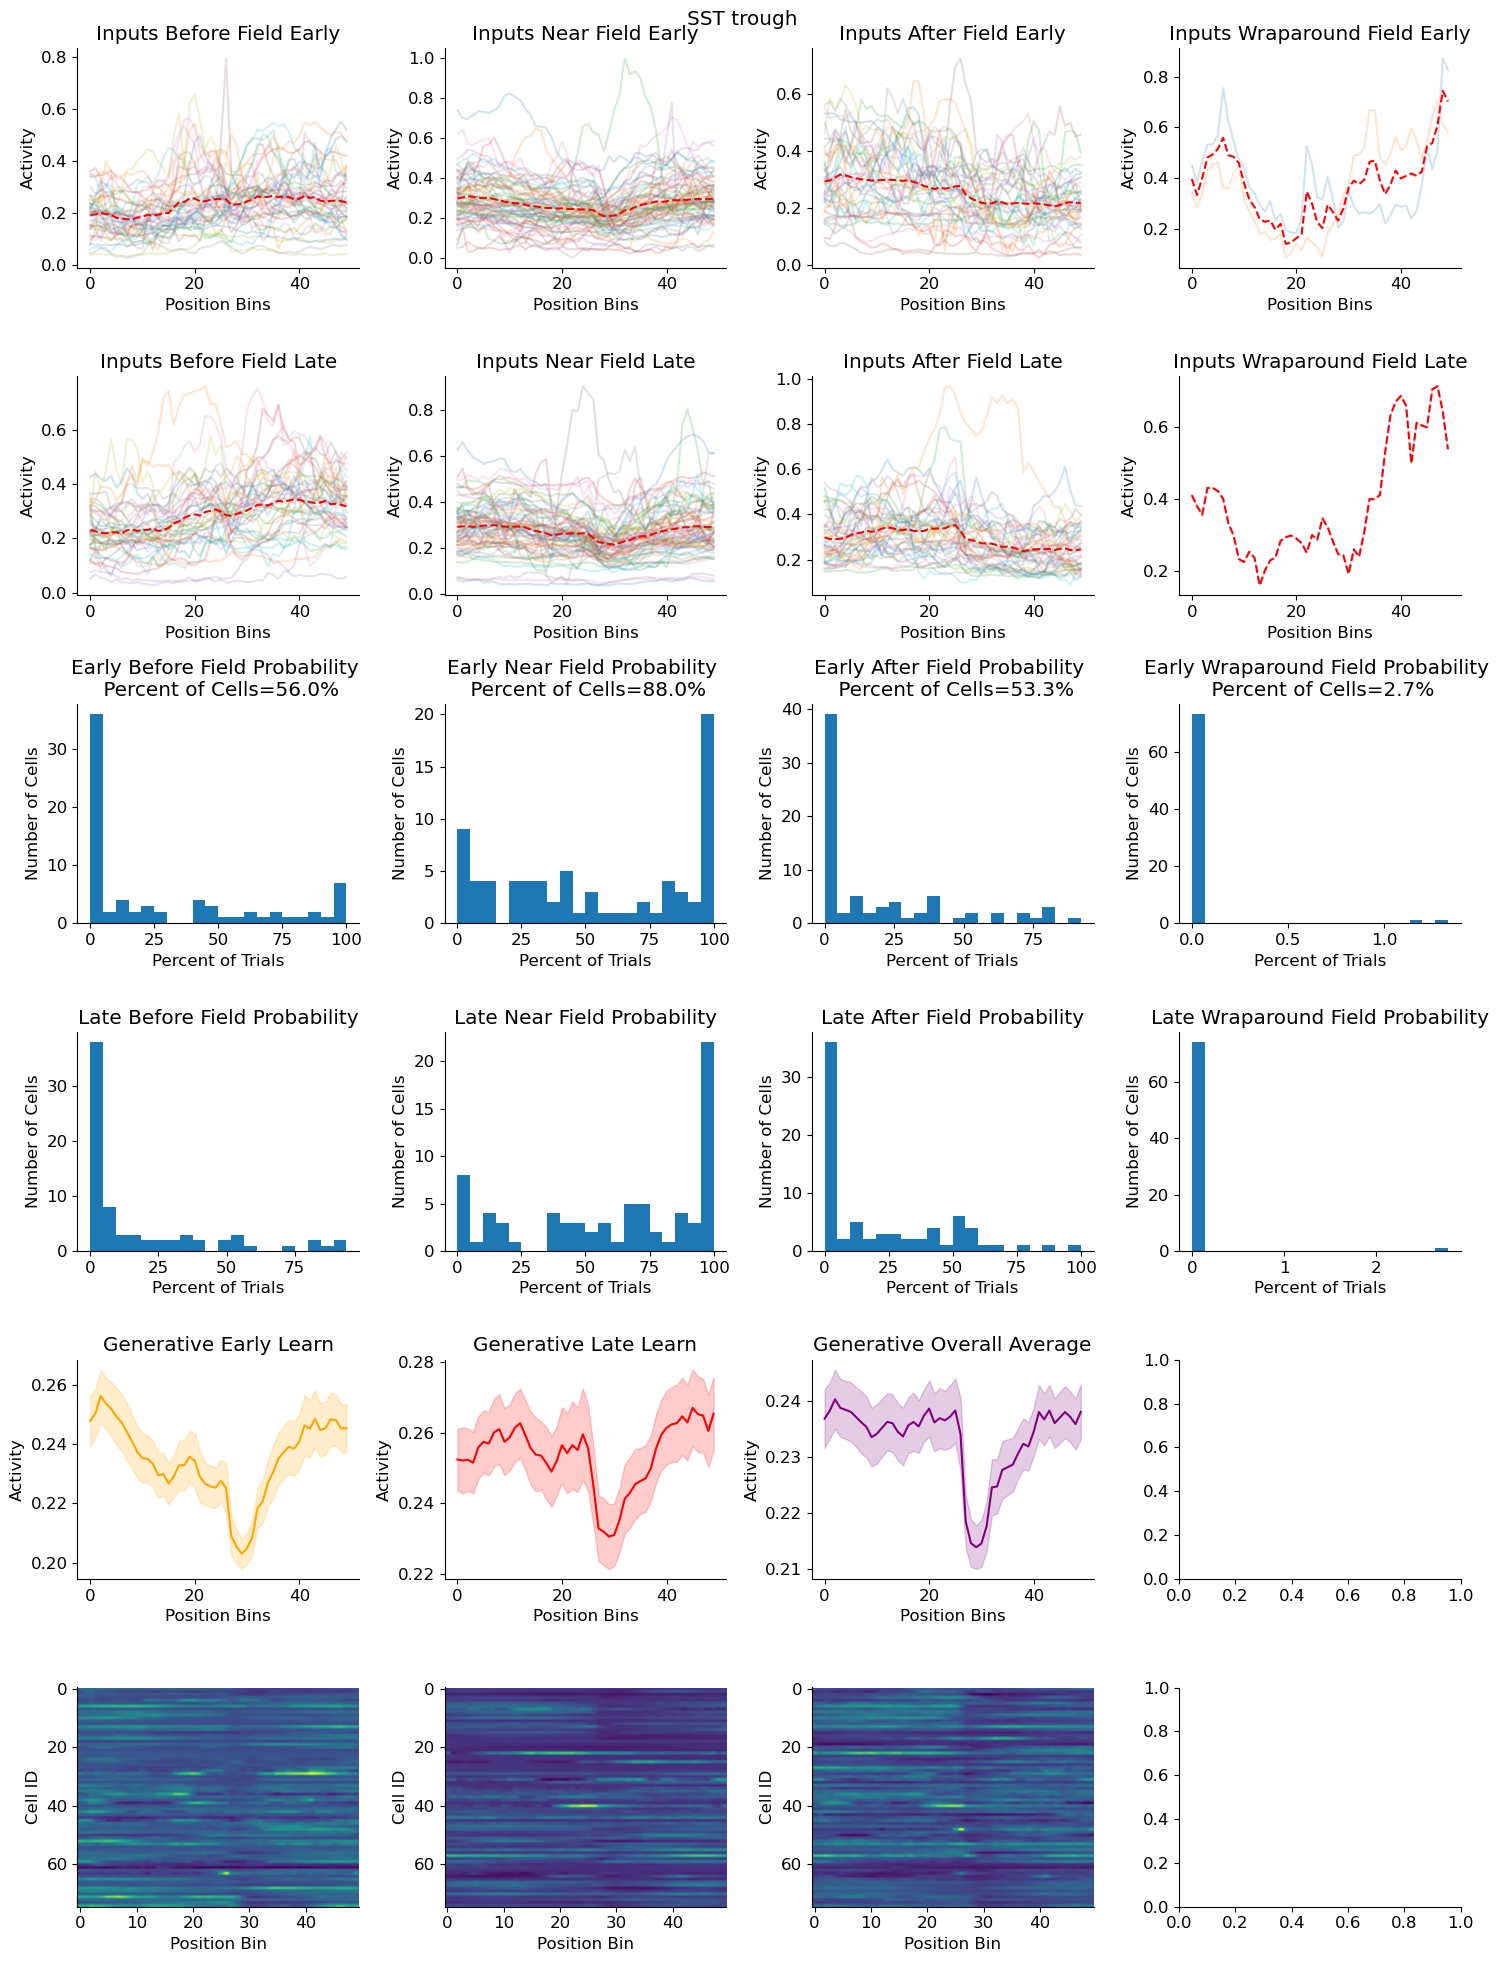

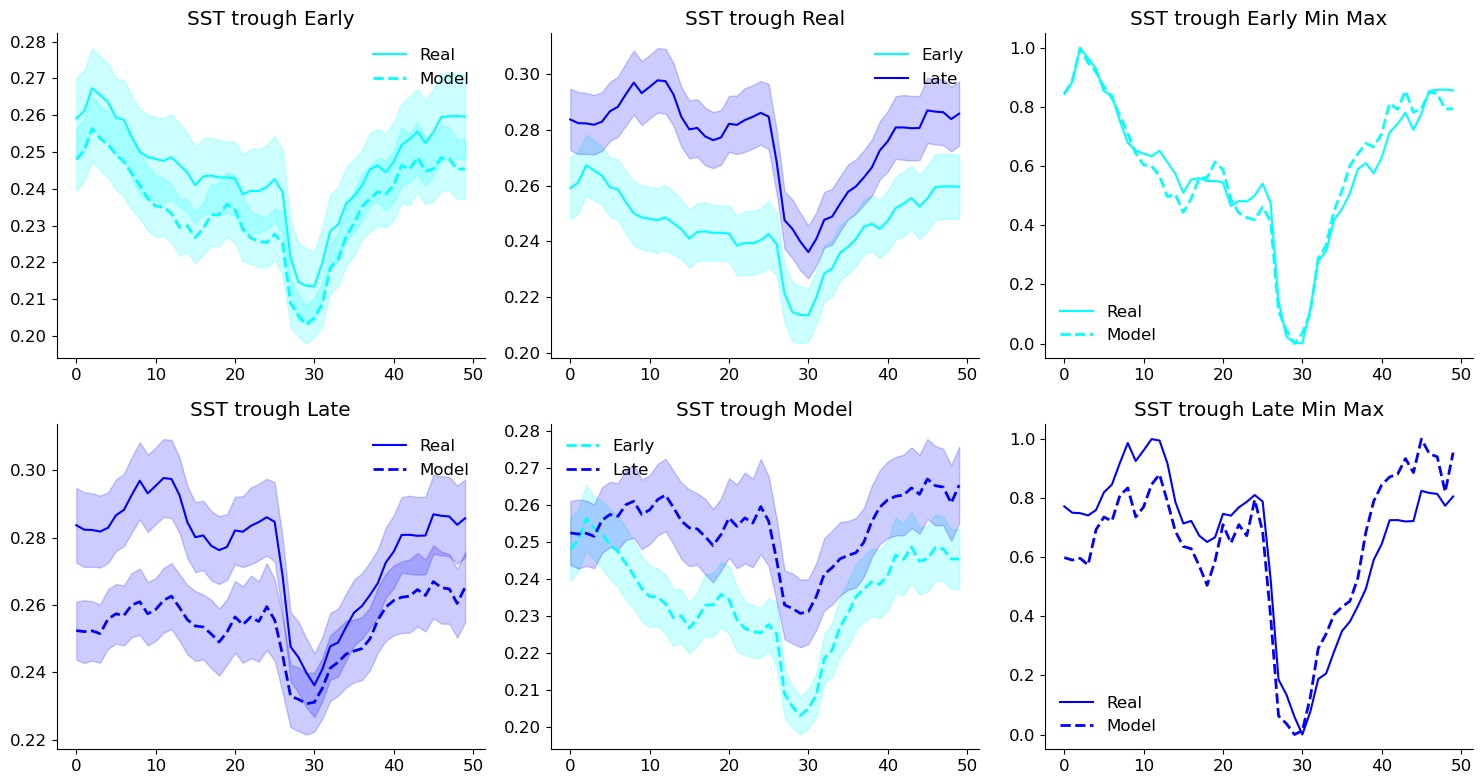

In [ ]:
early_data_list_dict = [before_field_array_early_trough_SST_dict, near_field_array_early_trough_SST_dict, after_field_array_early_trough_SST_dict, wraparound_field_array_early_trough_SST_dict] 
late_data_list_dict = [before_field_array_late_trough_SST_dict, near_field_array_late_trough_SST_dict, after_field_array_late_trough_SST_dict, wraparound_field_array_late_trough_SST_dict]
middle_data_list_dict = [before_field_array_middle_trough_SST_dict, near_field_array_middle_trough_SST_dict, after_field_array_middle_trough_SST_dict, wraparound_field_array_middle_trough_SST_dict]

inits=0.2
vol=0.01

reconstruct_activity_from_clusters_every_cell_diff_latent_split(cell_SST_model_ranks20_contig_x00, residual_activity_dict_SST, early_data_list_dict, late_data_list_dict, middle_data_list_dict, percent_lists_SST_early_trough, percent_lists_SST_late_trough, percent_lists_SST_middle_trough, percent_of_cells_list_SST_early_trough, percent_of_cells_list_SST_late_trough, percent_of_cells_list_SST_middle_trough, inits, vol, cell_type="SST trough", plot=True, num_t_e=20, num_t_m=40, num_t_l=20)
cell_list_early_SST_trough, cell_list_late_SST_trough, cell_list_middle_SST_trough, full_activity_list_SST_trough, trial_averaged_cell_array_early_SST_trough, trial_averaged_cell_array_late_SST_trough, full_activity_trial_av_array_SST_trough = reconstruct_activity_from_clusters_every_cell_diff_latent_split(cell_SST_model_ranks20_contig_x00, residual_activity_dict_SST, early_data_list_dict, late_data_list_dict, middle_data_list_dict, percent_lists_SST_early_trough, percent_lists_SST_late_trough, percent_lists_SST_middle_trough, percent_of_cells_list_SST_early_trough, percent_of_cells_list_SST_late_trough, percent_of_cells_list_SST_middle_trough, inits, vol, cell_type="SST trough", plot=False, num_t_e=20, num_t_m=40, num_t_l=20)
compare_within_subtype(cell_SST_model_ranks20_contig_x00, trial_averaged_cell_array_early_SST_trough, trial_averaged_cell_array_late_SST_trough, full_activity_trial_av_array_SST_trough, residual_activity_dict_SST, cell_type="SST trough")



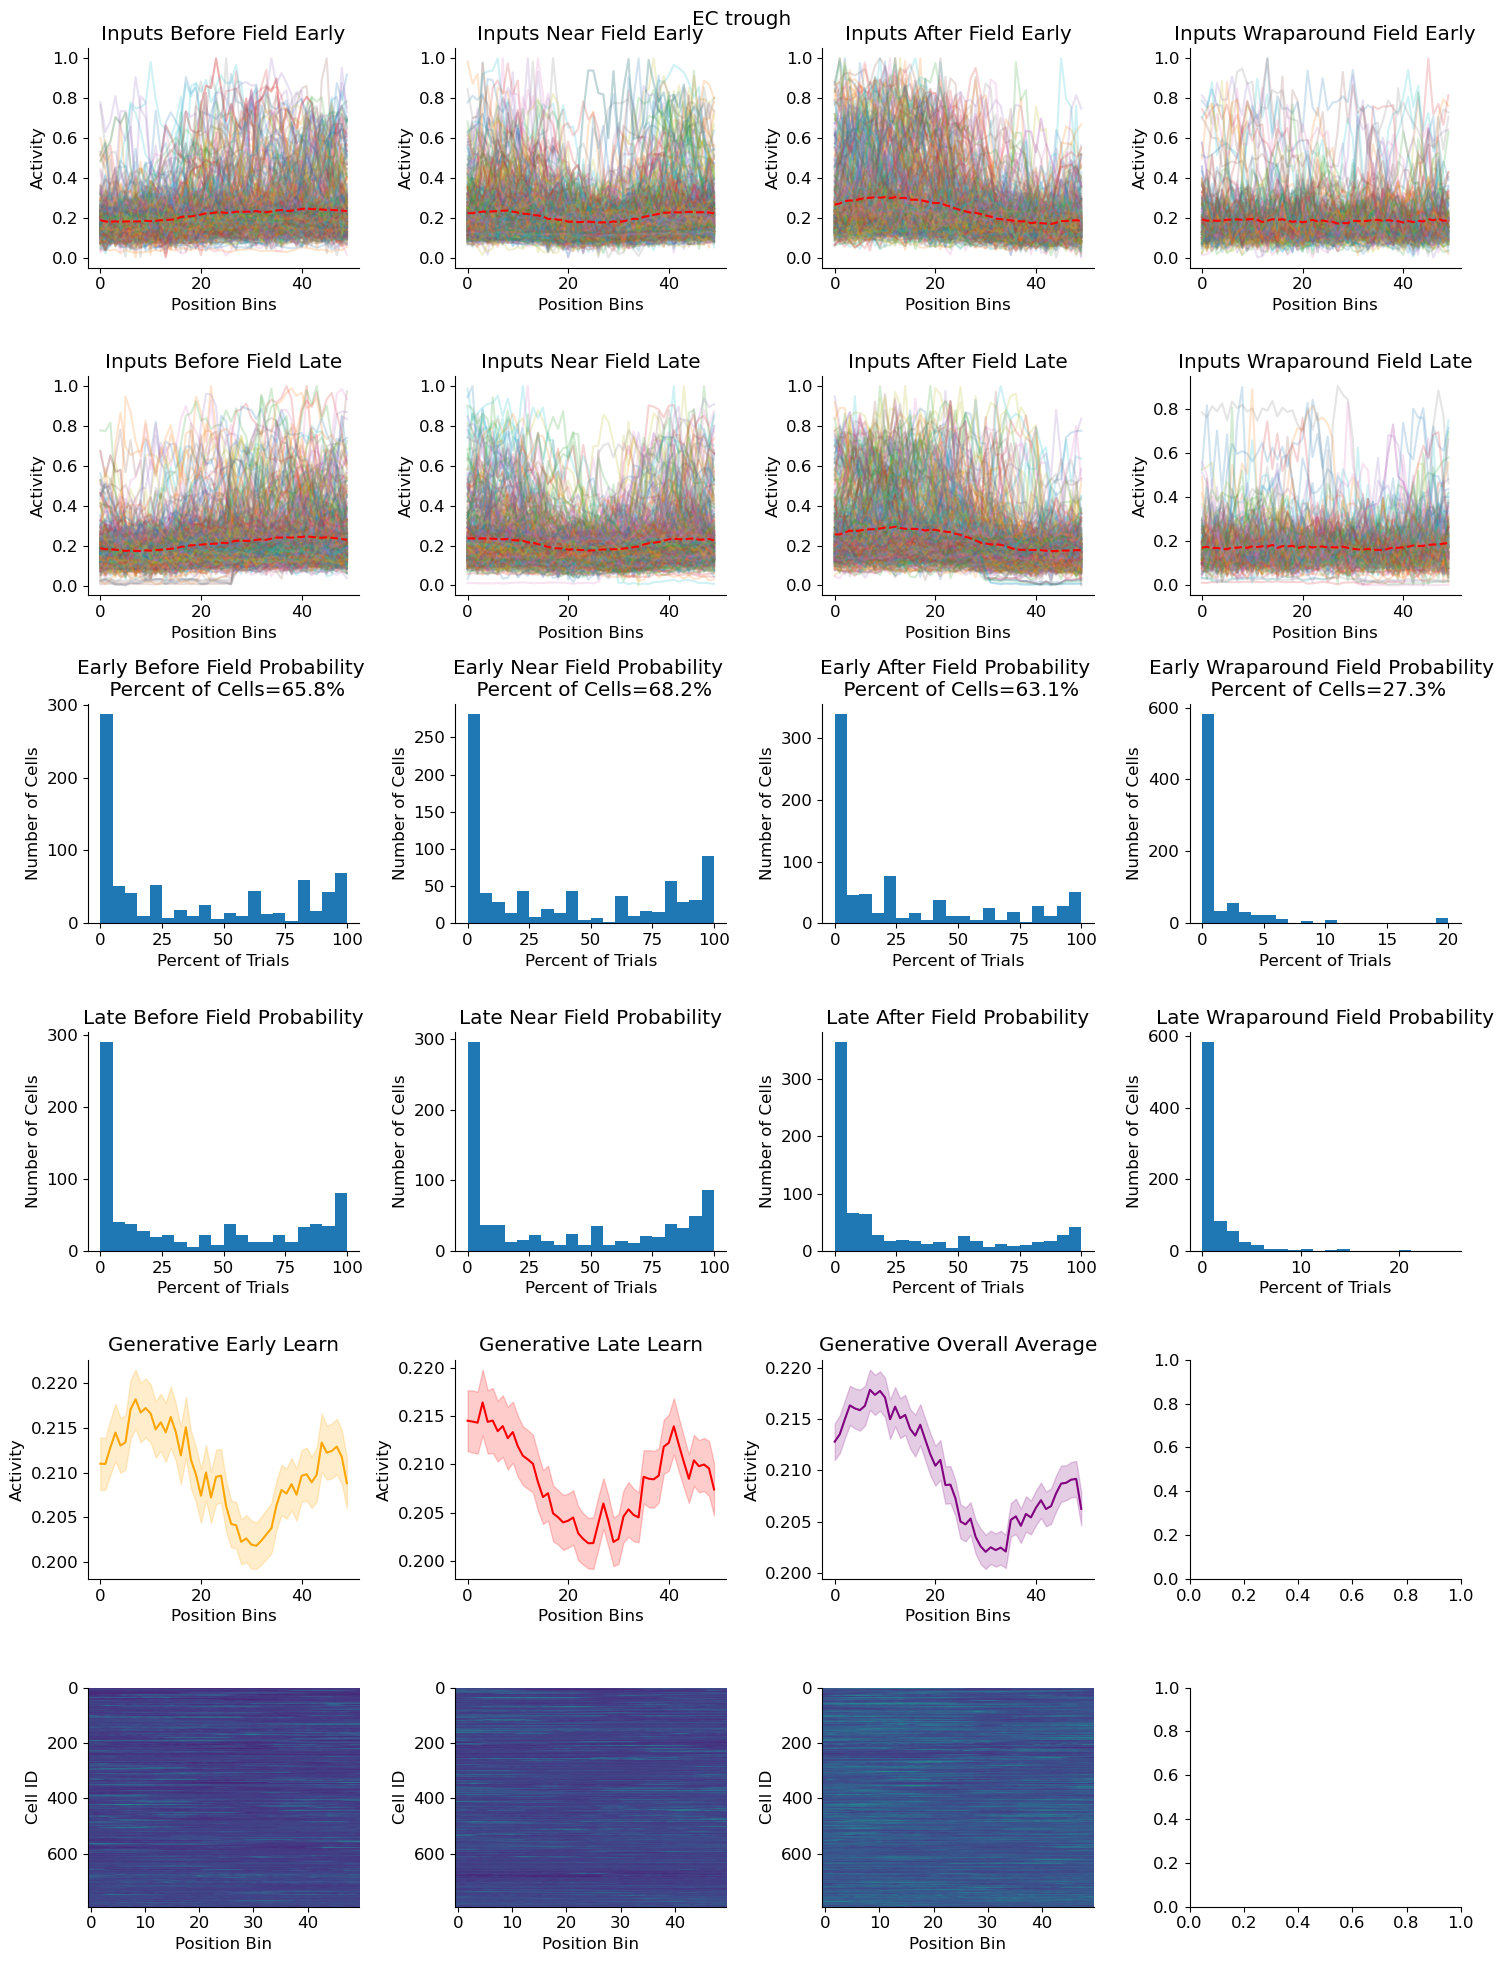

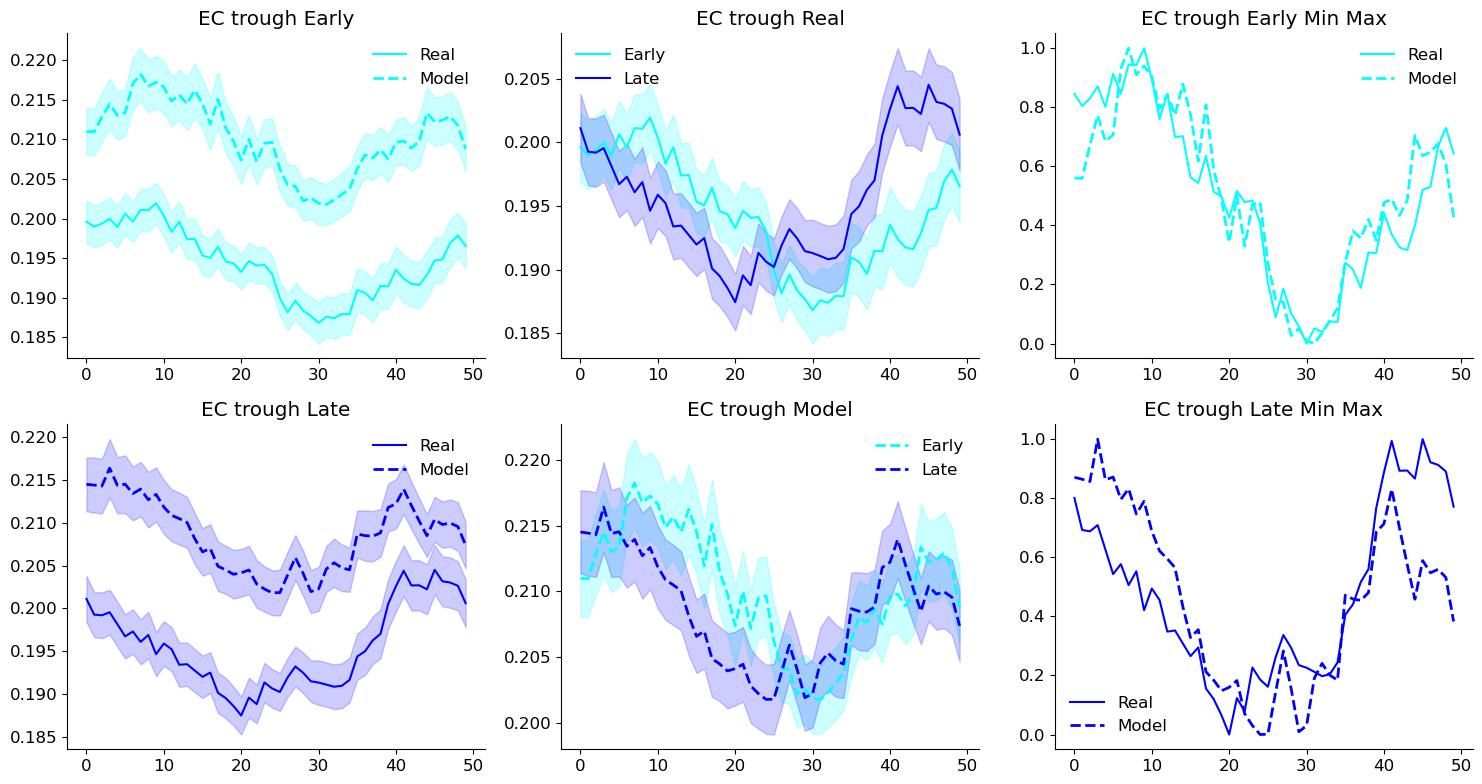

In [ ]:
early_data_list_dict = [before_field_array_early_trough_EC_dict, near_field_array_early_trough_EC_dict, after_field_array_early_trough_EC_dict, wraparound_field_array_early_trough_EC_dict] 
late_data_list_dict = [before_field_array_late_trough_EC_dict, near_field_array_late_trough_EC_dict, after_field_array_late_trough_EC_dict, wraparound_field_array_late_trough_EC_dict]
middle_data_list_dict = [before_field_array_middle_trough_EC_dict, near_field_array_middle_trough_EC_dict, after_field_array_middle_trough_EC_dict, wraparound_field_array_middle_trough_EC_dict]

inits=0.2
vol=0.01

reconstruct_activity_from_clusters_every_cell_diff_latent_split(cell_EC_model_ranks20_contig_x00, residual_activity_dict_EC, early_data_list_dict, late_data_list_dict, middle_data_list_dict, percent_lists_EC_early_trough, percent_lists_EC_late_trough, percent_lists_EC_middle_trough, percent_of_cells_list_EC_early_trough, percent_of_cells_list_EC_late_trough, percent_of_cells_list_EC_middle_trough, inits, vol, cell_type="EC trough", plot=True, num_t_e=20, num_t_m=40, num_t_l=20)
cell_list_early_EC_trough, cell_list_late_EC_trough, cell_list_middle_EC_trough, full_activity_list_EC_trough, trial_averaged_cell_array_early_EC_trough, trial_averaged_cell_array_late_EC_trough, full_activity_trial_av_array_EC_trough = reconstruct_activity_from_clusters_every_cell_diff_latent_split(cell_EC_model_ranks20_contig_x00, residual_activity_dict_EC, early_data_list_dict, late_data_list_dict, middle_data_list_dict, percent_lists_EC_early_trough, percent_lists_EC_late_trough, percent_lists_EC_middle_trough, percent_of_cells_list_EC_early_trough, percent_of_cells_list_EC_late_trough, percent_of_cells_list_EC_middle_trough, inits, vol, cell_type="EC trough", plot=False, num_t_e=20, num_t_m=40, num_t_l=20)
compare_within_subtype(cell_EC_model_ranks20_contig_x00, trial_averaged_cell_array_early_EC_trough, trial_averaged_cell_array_late_EC_trough, full_activity_trial_av_array_EC_trough, residual_activity_dict_EC, cell_type="EC trough")



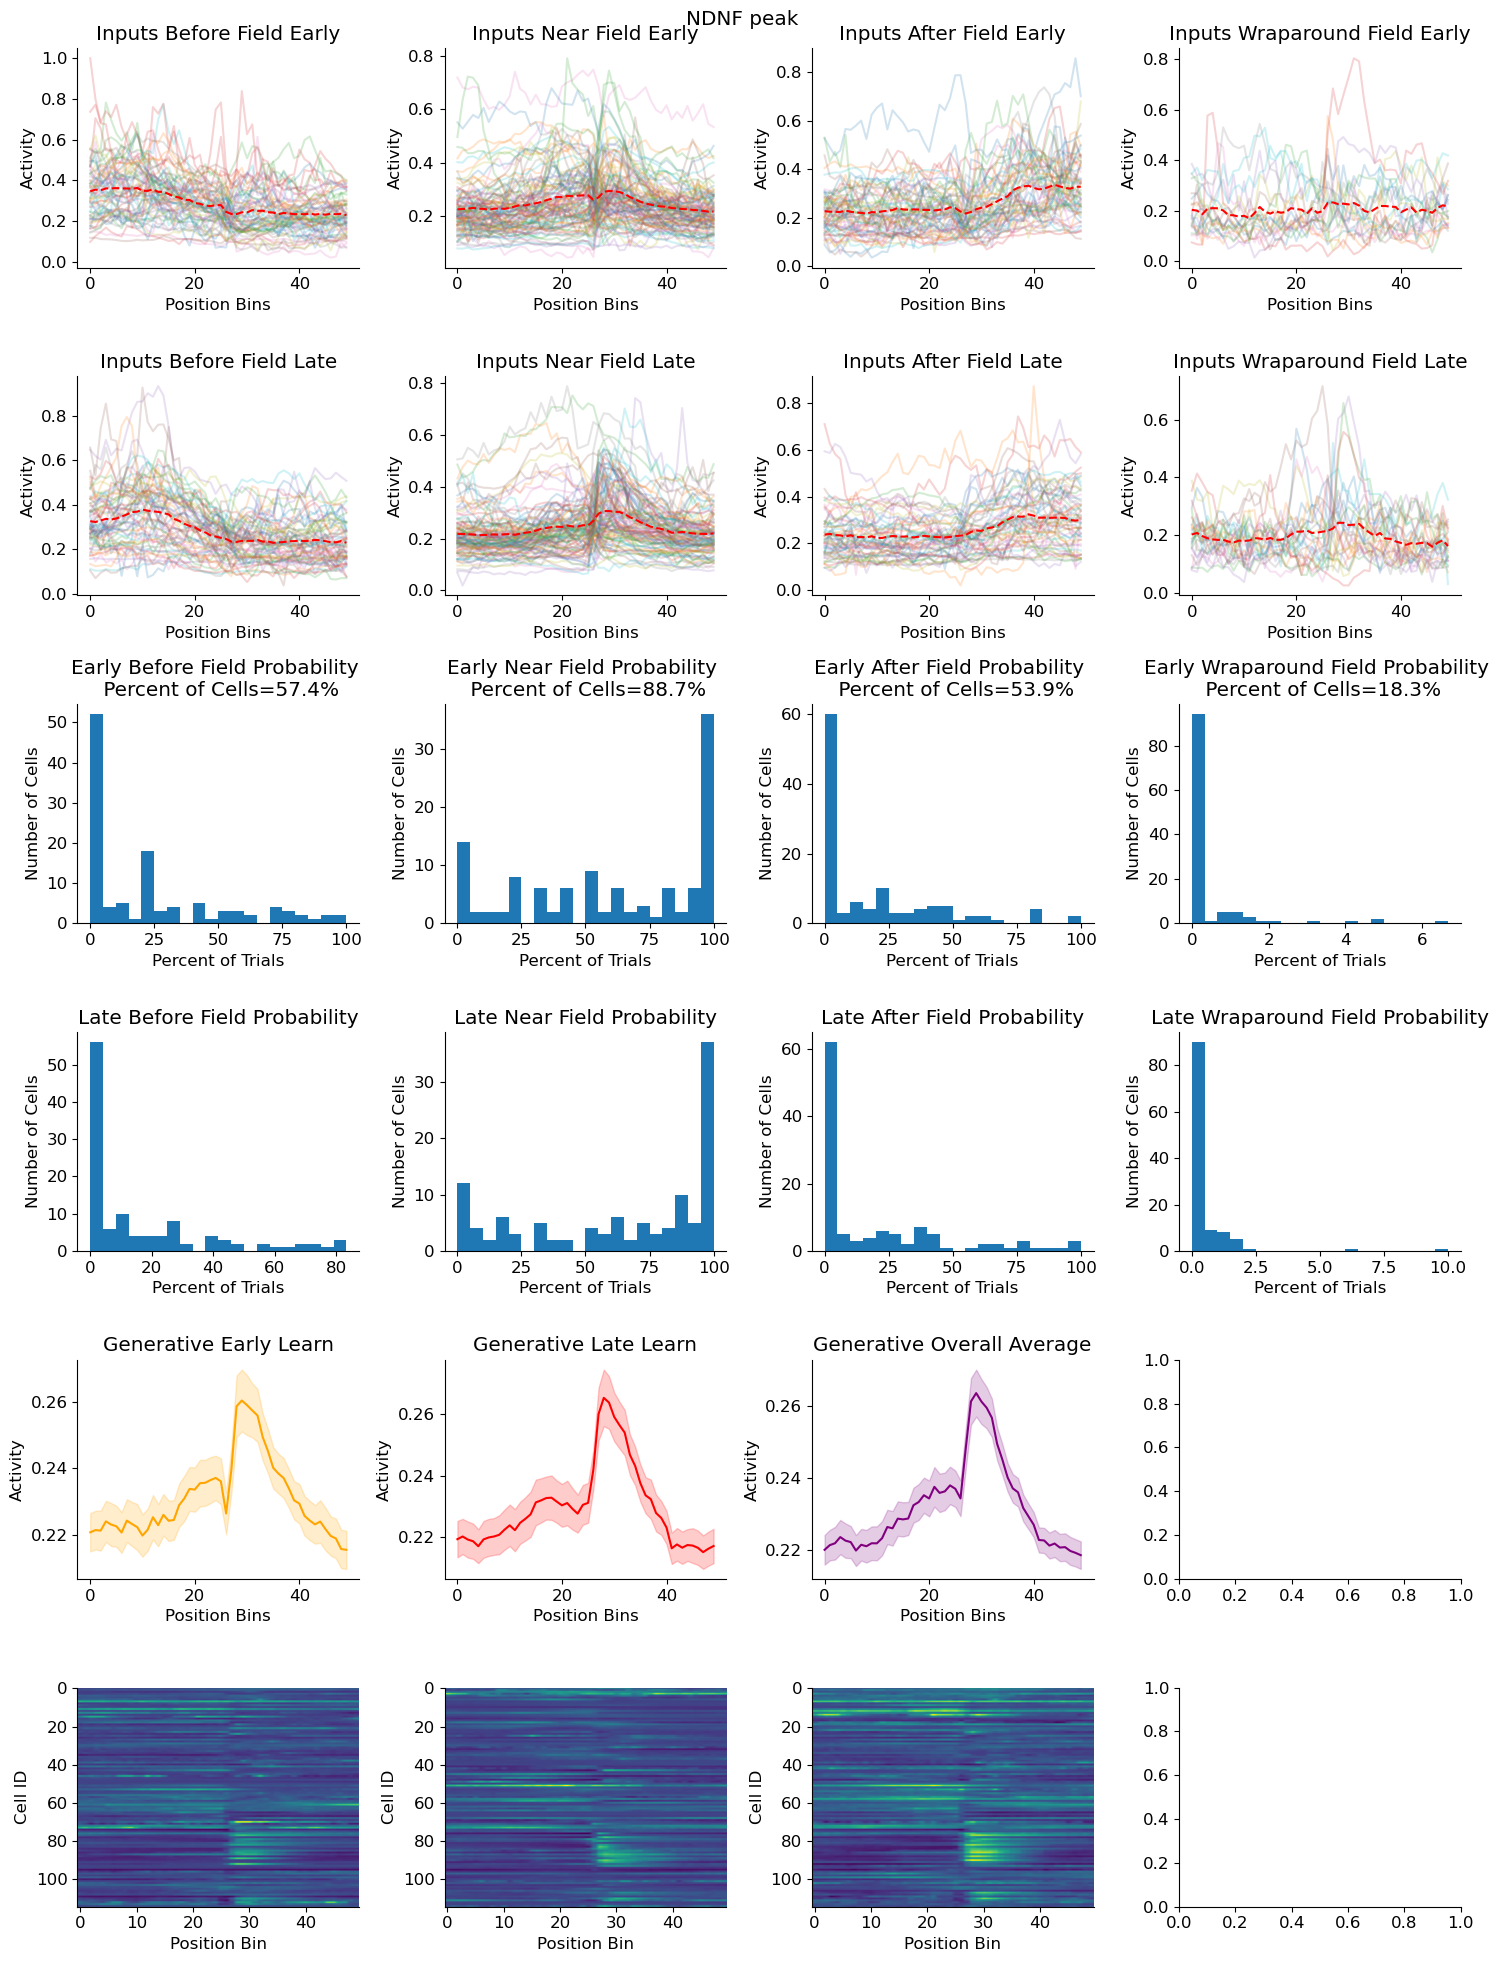

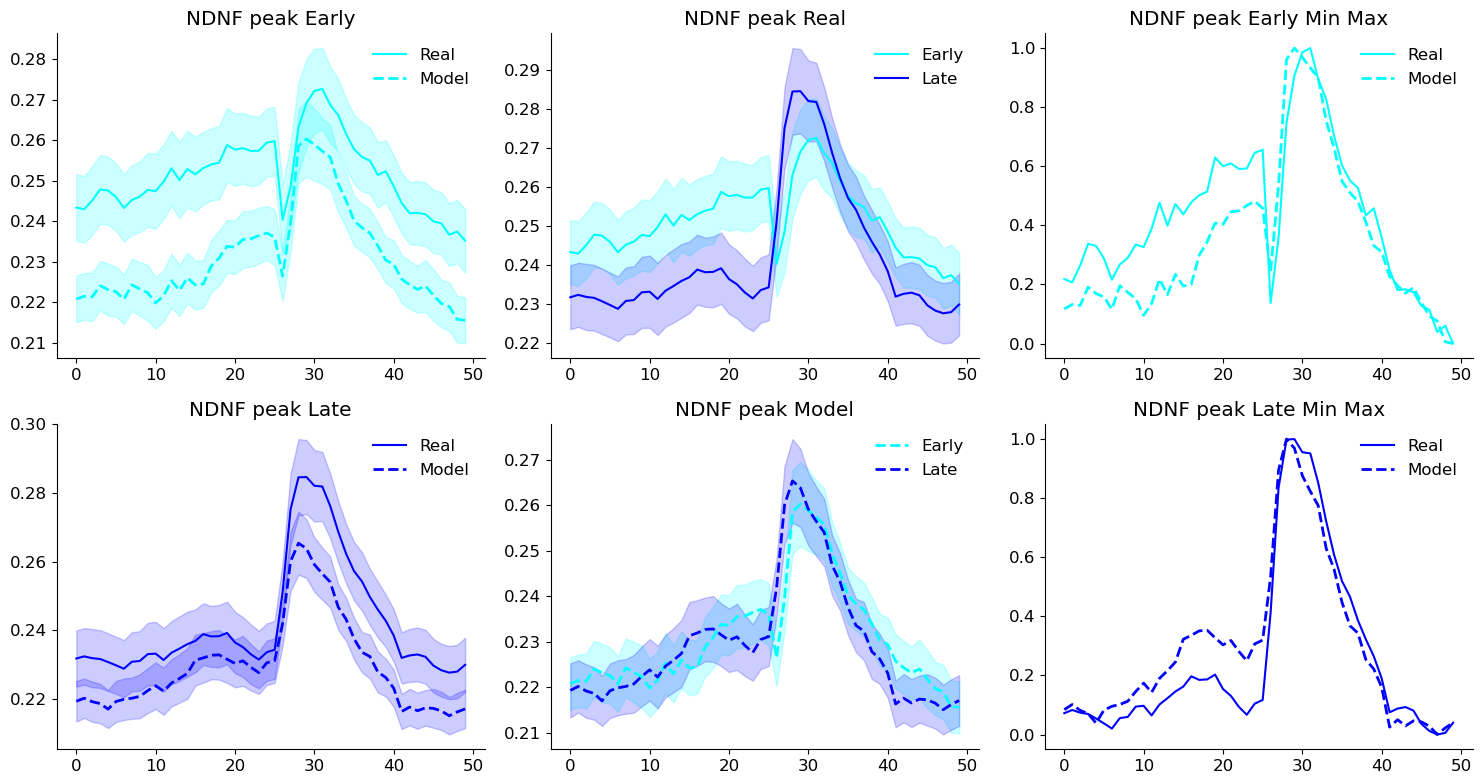

In [ ]:
early_data_list_dict = [before_field_array_early_peak_NDNF_dict, near_field_array_early_peak_NDNF_dict, after_field_array_early_peak_NDNF_dict, wraparound_field_array_early_peak_NDNF_dict] 
late_data_list_dict = [before_field_array_late_peak_NDNF_dict, near_field_array_late_peak_NDNF_dict, after_field_array_late_peak_NDNF_dict, wraparound_field_array_late_peak_NDNF_dict]
middle_data_list_dict = [before_field_array_middle_peak_NDNF_dict, near_field_array_middle_peak_NDNF_dict, after_field_array_middle_peak_NDNF_dict, wraparound_field_array_middle_peak_NDNF_dict]

inits=0.2
vol=0.01

reconstruct_activity_from_clusters_every_cell_diff_latent_split(fixed_cell_NDNF_model_ranks20_contig_x00_cue, fixed_residual_activity_dict_NDNF_newest, early_data_list_dict, late_data_list_dict, middle_data_list_dict, percent_lists_NDNF_early_peak, percent_lists_NDNF_late_peak, percent_lists_NDNF_middle_peak, percent_of_cells_list_NDNF_early_peak, percent_of_cells_list_NDNF_late_peak, percent_of_cells_list_NDNF_middle_peak, inits, vol, cell_type="NDNF peak", plot=True, num_t_e=20, num_t_m=40, num_t_l=20)
cell_list_early_NDNF_peak, cell_list_late_NDNF_peak, cell_list_middle_NDNF_peak, full_activity_list_NDNF_peak, trial_averaged_cell_array_early_NDNF_peak, trial_averaged_cell_array_late_NDNF_peak, full_activity_trial_av_array_NDNF_peak = reconstruct_activity_from_clusters_every_cell_diff_latent_split(fixed_cell_NDNF_model_ranks20_contig_x00_cue, fixed_residual_activity_dict_NDNF_newest, early_data_list_dict, late_data_list_dict, middle_data_list_dict, percent_lists_NDNF_early_peak, percent_lists_NDNF_late_peak, percent_lists_NDNF_middle_peak, percent_of_cells_list_NDNF_early_peak, percent_of_cells_list_NDNF_late_peak, percent_of_cells_list_NDNF_middle_peak, inits, vol, cell_type="NDNF peak", plot=False, num_t_e=20, num_t_m=40, num_t_l=20)
compare_within_subtype(fixed_cell_NDNF_model_ranks20_contig_x00_cue, trial_averaged_cell_array_early_NDNF_peak, trial_averaged_cell_array_late_NDNF_peak, full_activity_trial_av_array_NDNF_peak, fixed_residual_activity_dict_NDNF_newest, cell_type="NDNF peak")



In [ ]:
def loss_fn(params, EC, NDNF, SST):
    ndnf_sf, sst_sf = params
    summed = EC - (ndnf_sf * NDNF + sst_sf * SST)
    main_loss = np.mean(np.abs(summed))
    equal_scaling_penalty = np.abs(ndnf_sf - sst_sf)
    return main_loss + 50 * equal_scaling_penalty

def loss_fn_no_NDNF(params, EC, SST):
    sst_sf = params
    summed = EC - (sst_sf * SST)
    main_loss = np.mean(np.abs(summed))
#     equal_scaling_penalty = np.abs(ndnf_sf - sst_sf)
    return main_loss + 50 #* equal_scaling_penalty

from scipy.optimize import minimize

def get_input_scaling_factors(NDNF_input_summed, EC_input_summed, SST_input_summed):
    initial_guess = [1.0, 1.0]

    # Optimize with additional args for loss_fn
    result = minimize(
        loss_fn,
        initial_guess,
        args=(EC_input_summed, NDNF_input_summed, SST_input_summed),
        method='Nelder-Mead'
    )

    NDNF_sf_opt, SST_sf_opt = result.x
    print("Best NDNF_sf:", NDNF_sf_opt)
    print("Best SST_sf:", SST_sf_opt)
    
    return NDNF_sf_opt, SST_sf_opt


def get_input_scaling_factors_no_NDNF(EC_input_summed, SST_input_summed):
    initial_guess = [1.0]

    # Optimize with additional args for loss_fn
    result = minimize(
        loss_fn_no_NDNF,
        initial_guess,
        args=(EC_input_summed, SST_input_summed),
        method='Nelder-Mead'
    )

    SST_sf_opt = result.x
    print("Best SST_sf:", SST_sf_opt)
    
    return SST_sf_opt



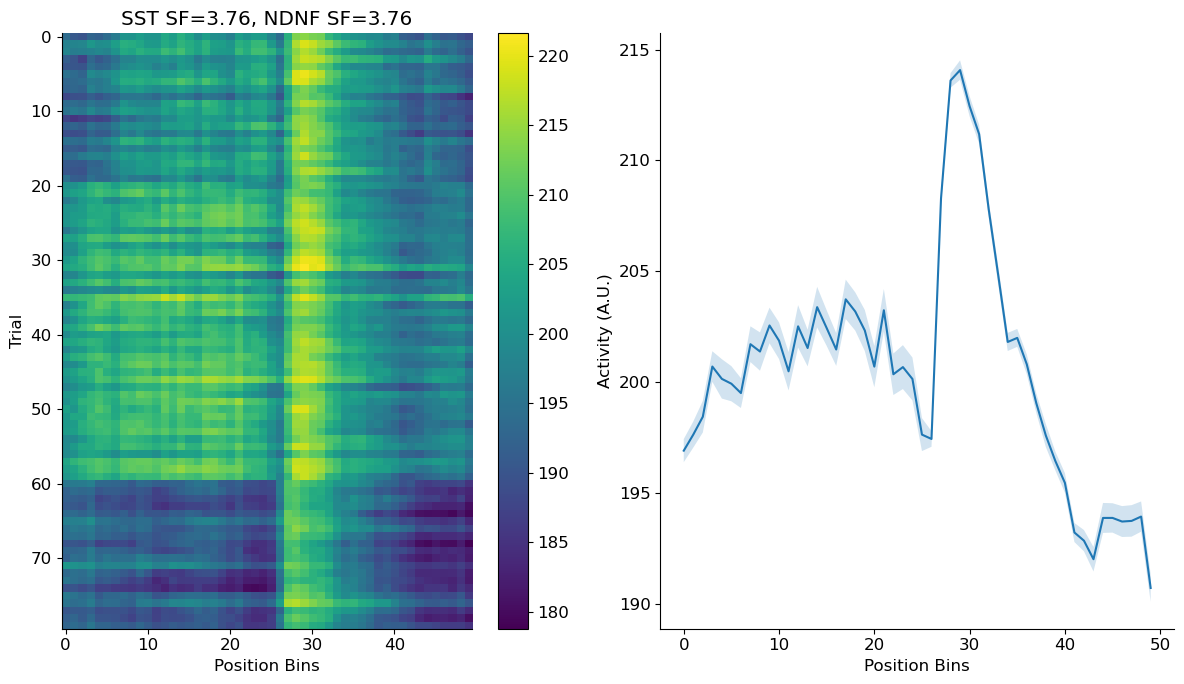

In [ ]:
def plot_the_dend(EC_input_summed, SST_input_summed, NDNF_input_summed, SST_sf=SST_sf_opt, NDNF_sf=NDNF_sf_opt, include_inhibition=True, plot=True):

    if include_inhibition:
        dend = EC_input_summed - (SST_input_summed*SST_sf) + (NDNF_input_summed*NDNF_sf)
    else:
        dend = EC_input_summed
    
    if plot:
        fig, axs = plt.subplots(1,2, figsize=(12,7))

        im = axs[0].imshow(dend.T, aspect='auto')
        axs[0].set_ylabel("Trial")
        axs[0].set_xlabel("Position Bins")
        axs[0].set_title(f"SST SF={SST_sf:.2f}, NDNF SF={NDNF_sf:.2f}")
        fig.colorbar(im, ax=axs[0])

        mean_dend = np.mean(dend, axis=1)
        sem_dend = sem(dend, axis=1)

        axs[1].plot(mean_dend)
        axs[1].fill_between(range(len(mean_dend)), mean_dend+sem_dend, mean_dend-sem_dend, alpha=0.2)
        axs[1].set_ylabel("Activity (A.U.)")
        axs[1].set_xlabel("Position Bins")
        plt.tight_layout()
        plt.show()
    else:
        return dend

def get_summed_activity(cell_list_early_EC_trough):
    EC_input_early = np.array(cell_list_early_EC_trough)
    EC_input_summed_early = np.sum(EC_input_early, axis=0)
    return EC_input_summed_early


plot_the_dend(EC_input_summed, SST_input_summed, NDNF_input_summed, SST_sf=SST_sf_opt, NDNF_sf=NDNF_sf_opt)

In [ ]:
def get_real_velocity_array(filtered_factors_dict_EC, filtered_factors_dict_SST, fixed_filtered_factors_dict_NDNF_newest):
    new_average_vel = []

    for animal in filtered_factors_dict_EC:
        for cell in filtered_factors_dict_EC[animal]:
            new_average_vel.append(np.mean(filtered_factors_dict_EC[animal][cell], axis=1))

    for animal in filtered_factors_dict_SST:
        for cell in filtered_factors_dict_SST[animal]:
            new_average_vel.append(np.mean(filtered_factors_dict_SST[animal][cell], axis=1))

    for animal in fixed_filtered_factors_dict_NDNF_newest:
        for cell in fixed_filtered_factors_dict_NDNF_newest[animal]:
            new_average_vel.append(np.mean(fixed_filtered_factors_dict_NDNF_newest[animal][cell], axis=1))


    new_average_vel_array = np.array(new_average_vel)
    mean_new_average_vel_array = np.mean(new_average_vel_array, axis=0)
    
    return mean_new_average_vel_array


In [ ]:
full_activity_list_EC_trough_array = np.array(full_activity_list_EC_trough)
full_activity_list_EC_trough_array.shape

(792, 50, 80)

In [ ]:
    ax = axs_list[1]
    ax.set_title("Group1: per-cell")
    for cell in most_expressed_label_dict_animal_cluster_1_all:
        arr_most = most_expressed_label_dict_animal_cluster_1_all[cell]["cluster_activity"]
        arr_least = least_expressed_label_dict_animal_all_group1[cell]["cluster_activity"]
        arr_most_mean = np.mean(arr_most, axis=1)  # avg over trials/time dim as you intended
        arr_least_mean = np.mean(arr_least, axis=1)
        mean_1_list_most.append(arr_most_mean)
        mean_1_list_least.append(arr_least_mean)
        ax.plot(arr_most_mean, alpha=1.4)
        most_mean_1_fractions_list.append(most_expressed_label_dict_animal_cluster_1_all[cell]["fraction"])
        least_mean_1_fractions_list.append(most_expressed_label_dict_animal_cluster_1_all[cell]["fraction"])

In [ ]:
############### need the contribution 


def get_dend_contr(residual_activity_dict_EC, full_activity_list_EC_trough, mean_new_average_vel_array, GLM_params, vel=23, norm=False, add_vel_contribution=False, const_vel=True, raw_data_return_constant_vel=True):

    dendrite_contribution_list = []

    counter=0

    for animal in residual_activity_dict_EC:
        for cell in residual_activity_dict_EC[animal]:
            data = full_activity_list_EC_trough[counter]
            counter+=1

            weights = GLM_params[animal][cell]['weights']["Velocity"]
            intercept = GLM_params[animal][cell]['intercept']

            if const_vel:
                animal_velocity = np.full((data.shape), vel)

                data = data + (weights * animal_velocity) + intercept



            elif add_vel_contribution:
                animal_velocity = np.tile(mean_new_average_vel_array[:, np.newaxis], (1, data.shape[1]))

                data = data + (weights * animal_velocity) + intercept

            else:
                data = data #+ intercept
                if raw_data_return_constant_vel:
                    animal_velocity = np.full((data.shape), vel)
                else:
                    animal_velocity = np.tile(mean_new_average_vel_array[:, np.newaxis], (1, data.shape[1]))

            if norm == "min_max":
                data = normalize(data, norm='min_max', per_cell=False) * 10

            dendrite_contribution_list.append(data)

    dendrite_contribution_array = np.array(dendrite_contribution_list)
    dendrite_contribution = np.sum(dendrite_contribution_array, axis=0)

    return dendrite_contribution, animal_velocity

In [ ]:
EC_input_summed

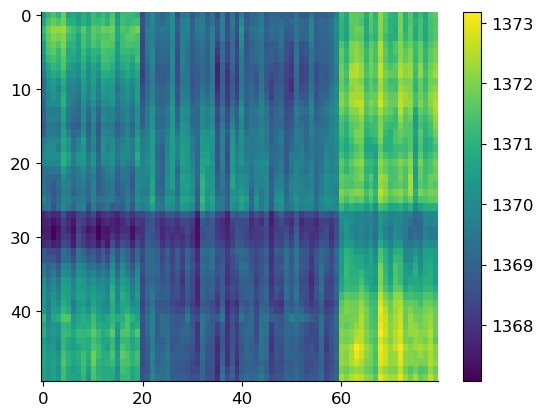

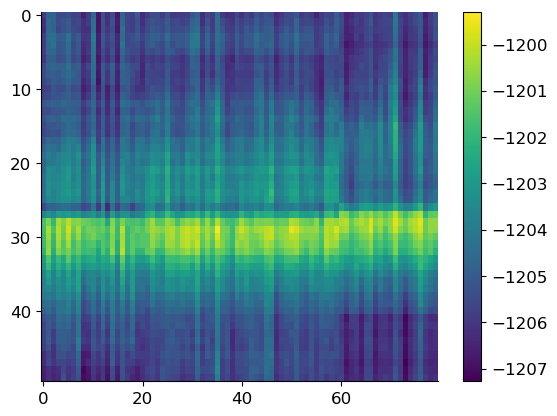

In [ ]:
sst = dendrite_contribution_SST #* SST_sf_opt
plt.imshow(sst, aspect='auto')
plt.colorbar()
plt.show()

ndnf = dendrite_contribution_NDNF #* NDNF_sf_opt
plt.imshow(ndnf, aspect='auto')
plt.colorbar()
plt.show()


Best NDNF_sf: 3.7570888205813104
Best SST_sf: 3.757088830254414


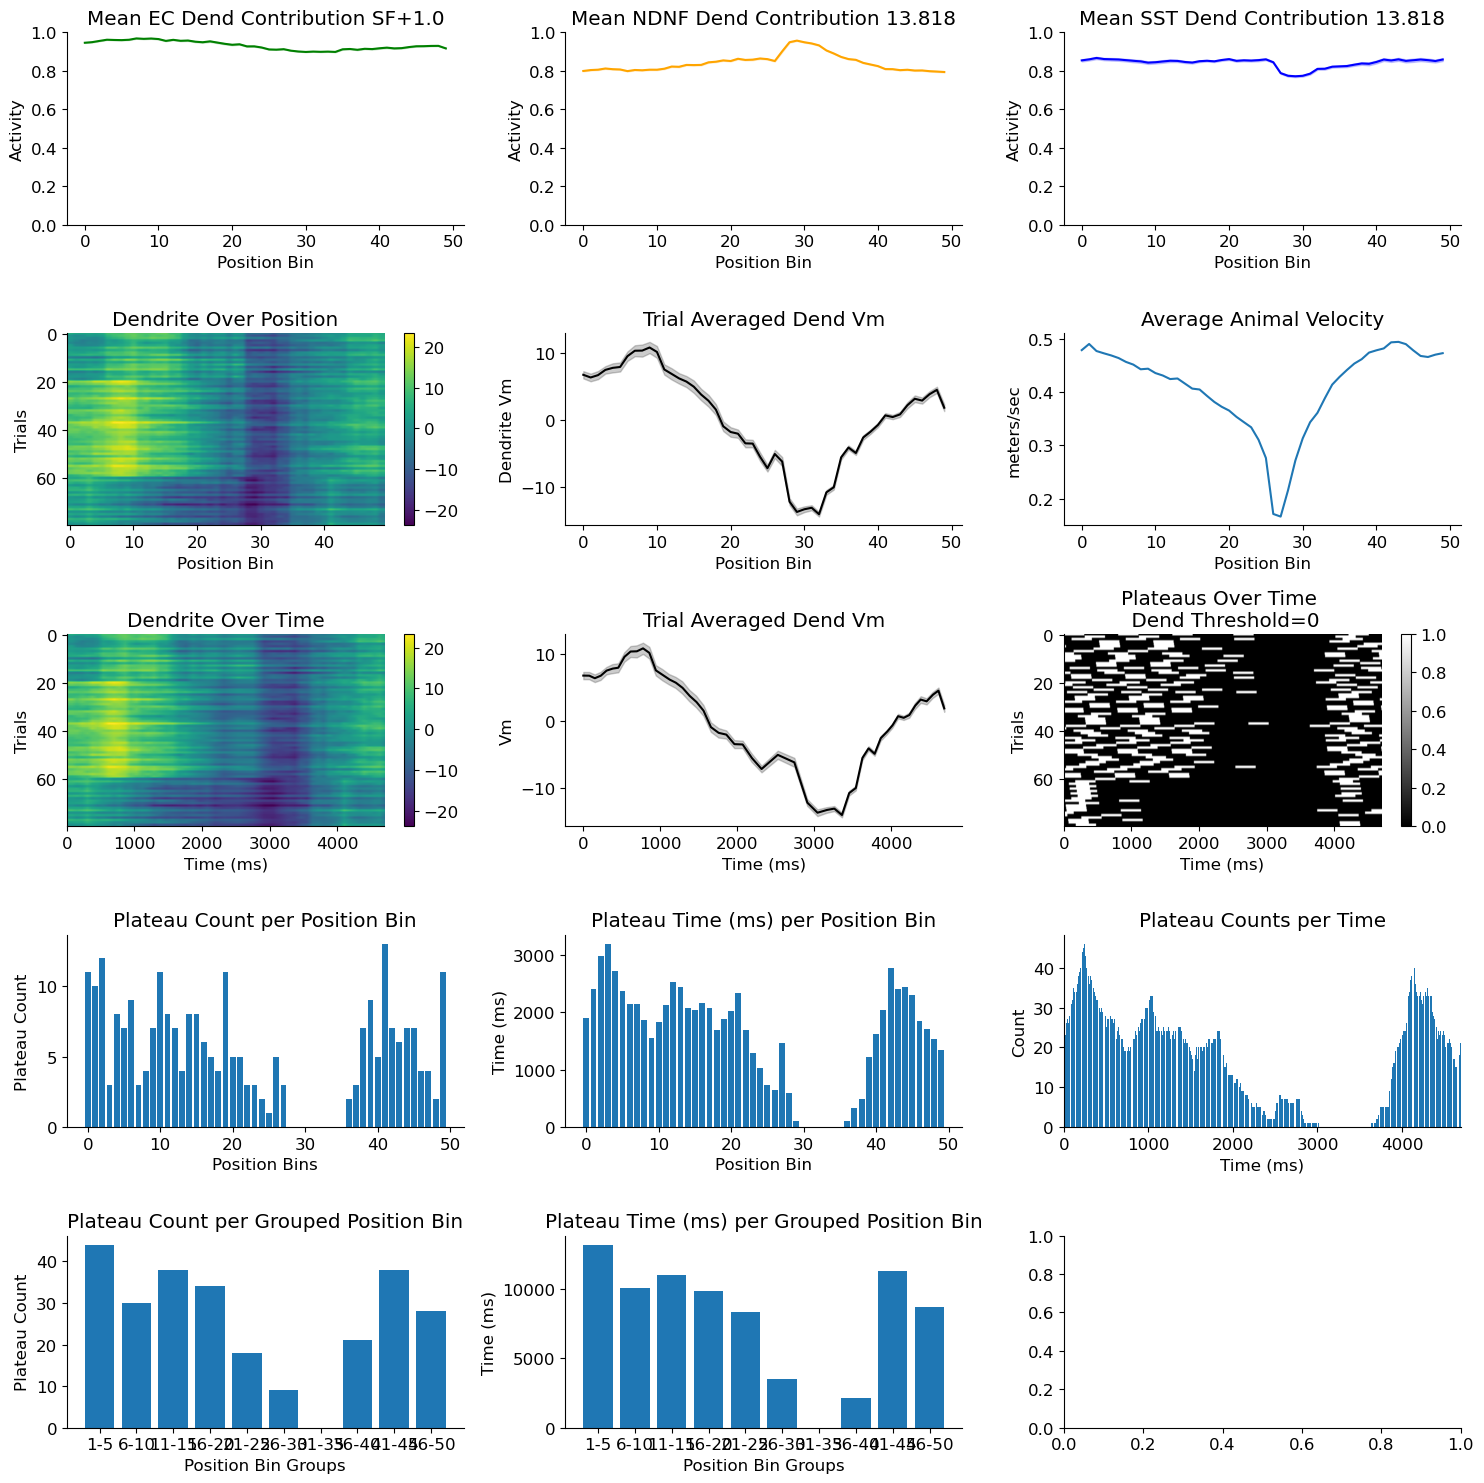

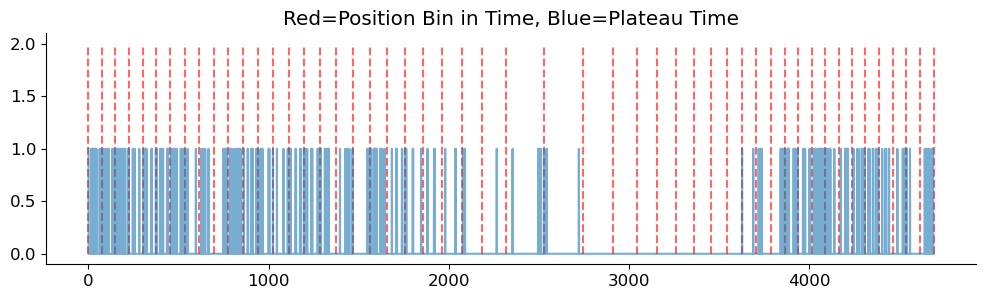

In [ ]:


def get_dend_plateaus(dendrite_contribution_EC, dendrite_contribution_SST, dendrite_contribution_NDNF, animal_velocity, vel_applied=None, dend_threshold=0, inc_inh=True, remove_NDNF=False):
    
    if inc_inh:
        if remove_NDNF:
            SST_sf_opt = get_input_scaling_factors_no_NDNF(EC_input_summed, SST_input_summed)
            summed_dendrite = dendrite_contribution_EC - ((dendrite_contribution_SST * SST_sf_opt)) #+ (dendrite_contribution_NDNF * NDNF_sf_opt))
        else:
            NDNF_sf_opt, SST_sf_opt = get_input_scaling_factors(dendrite_contribution_NDNF, dendrite_contribution_EC, dendrite_contribution_SST)
            summed_dendrite = dendrite_contribution_EC - ((dendrite_contribution_SST * SST_sf_opt) + (dendrite_contribution_NDNF * NDNF_sf_opt))
        
    else:
        summed_dendrite = dendrite_contribution_EC
    
    an_velocity = animal_velocity
    
    dx=180/50

    dt_constant = 0.001
    # dt = dx / animal_velocity_constant
    dt = dx / (an_velocity*100)

    # if vel_applied == "nothing":
    #     dt = dx / animal_velocity_constant
    time_bins = np.cumsum(dt, axis=0)
    time_bins_ms = time_bins * 1

    num_trials = summed_dendrite.shape[1]
    trial_warped_activity = []
    max_len = 0

    for t in range(num_trials):
        if np.any(np.isnan(time_bins[:, t])):
            continue
        total_time = time_bins[-1, t]

        time_axis_constant = np.arange(0, total_time, dt_constant)

        firing = summed_dendrite[:, t]

        warped_firing = np.interp(time_axis_constant, time_bins_ms[:,t], firing)

        trial_warped_activity.append(warped_firing)
        if len(warped_firing) > max_len:
            max_len = len(warped_firing)

    padded_warped_activity = np.full((num_trials, max_len), np.nan) 
    for i, trace in enumerate(trial_warped_activity):
        padded_warped_activity[i, :len(trace)] = trace

    time_bin_size_ms = 1

    mean_dend_time = np.mean(padded_warped_activity, axis=0)
    sem_dend_time = sem(padded_warped_activity, axis=0)

    num_bins = len(mean_dend_time)
    x_time_ms = np.arange(num_bins) * time_bin_size_ms  # x-axis in ms


    position_bins, num_trials = an_velocity.shape


    flat_padded_warped_activity = padded_warped_activity.flatten()
    flat_plateau_array = np.zeros_like(flat_padded_warped_activity)

    i = 0
    while i < len(flat_padded_warped_activity):
        if flat_padded_warped_activity[i] > dend_threshold:
            flat_plateau_array[i:i+300] = 1

            i += 800
        else:
            i += 100


    plateau_array = flat_plateau_array.reshape(padded_warped_activity.shape)

    num_time_bins = padded_warped_activity.shape[1]

    plateau_positions_counter = np.zeros(50)

    time_in_bin_counter = np.zeros(50)

    animal_velocity = an_velocity * 100

    if vel_applied=="nothing":
        animal_velocity= mean_new_average_vel_array[:, None] * np.ones((1, summed_dendrite.shape[1])) *100



    plateau_start_positions_counter = np.zeros(50)  

    plateau_start_times_list = []

    for trial in range(plateau_array.shape[0]):
        velocity_trial = animal_velocity[:, trial]
        #         velocity_trial = proper_velocity
        dt_trial = dx / velocity_trial  # in seconds
        time_each_pos_bin_starts = np.concatenate([[0], np.cumsum(dt_trial)])

        plateau_start_indices = np.where(np.diff(np.pad(plateau_array[trial], (1, 0))) == 1)[0]
        plateau_start_times = plateau_start_indices * dt_constant  # in seconds
        plateau_start_times_list.append(plateau_start_times)

        for pt_start_time in plateau_start_times:
            if pt_start_time != 0.0:
                for pos_idx in range(50):
                    if time_each_pos_bin_starts[pos_idx] <= pt_start_time < time_each_pos_bin_starts[pos_idx + 1]:
                        plateau_start_positions_counter[pos_idx] += 1
                        break




    for trial in range(plateau_array.shape[0]):

        velocity_trial = animal_velocity[:, trial]  


        dt_trial = dx / velocity_trial  # in seconds

    #     print(f"np.cumsum(dt_trial) {np.cumsum(dt_trial)}")

        time_each_pos_bin_starts = np.concatenate([[0], np.cumsum(dt_trial)])

        time_binss = np.arange(num_time_bins) * dt_constant  

        for t_idx, time_bin in enumerate(time_binss):
            if plateau_array[trial, t_idx] == 1:
                for pos_idx in range(50):
                    if time_each_pos_bin_starts[pos_idx] <= time_bin < time_each_pos_bin_starts[pos_idx + 1]:
                        plateau_positions_counter[pos_idx] += 1
                        break


        for t_idx, time_bin in enumerate(time_binss):
            for pos_idx in range(50):
                if time_each_pos_bin_starts[pos_idx] <= time_bin < time_each_pos_bin_starts[pos_idx + 1]:
                    time_in_bin_counter[pos_idx] += 1
                    break


    return summed_dendrite, an_velocity, padded_warped_activity, plateau_positions_counter, plateau_start_positions_counter, plateau_array, mean_dend_time, plateau_start_times_list, time_each_pos_bin_starts, x_time_ms, time_each_pos_bin_starts

    


def plot_single_dend(dend_contribution_EC, dend_contribution_SST, dend_contribution_NDNF, summed_dendrite, an_velocity, padded_warped_activity, plateau_positions_counter, plateau_start_positions_counter, plateau_array, mean_dend_time, x_time_ms, plateau_start_times_list, time_each_position_bin_starts, NDNF_sf_opt, SST_sf_opt, include_inhibition=True):

    fig, axs = plt.subplots(5, 3, figsize=(15, 15))  
#     plt.suptitle(f"include_inhibition={include_inhibition}, use_model_EC={use_model_EC}, use_residuals={use_residuals}, velocity modulation={vel_applied}")


    EC_normalized = dend_contribution_EC/ np.max(dend_contribution_EC)

    mean_EC_dend = np.mean(EC_normalized, axis=1)
    sem_EC_dend = sem(EC_normalized, axis=1)
    axs[0,0].plot(mean_EC_dend, color='g', label="EC Vel")
    axs[0,0].fill_between(range(len(mean_EC_dend)), mean_EC_dend+sem_EC_dend, mean_EC_dend-sem_EC_dend, alpha=0.2, color='g')
    axs[0,0].set_title(f"Mean EC Dend Contribution SF+{1.0}")
    axs[0,0].set_xlabel("Position Bin")
    axs[0,0].set_ylabel("Activity")
    axs[0,0].set_ylim(0,1)

    if include_inhibition:

        SST_normalized = dend_contribution_SST/ np.max(dend_contribution_SST)

        mean_SST_dend = np.mean(SST_normalized, axis=1)
        sem_SST_dend = sem(SST_normalized, axis=1)
        axs[0,2].plot(mean_SST_dend, color='b', label="SST Vel")
        axs[0,2].fill_between(range(len(mean_SST_dend)), mean_SST_dend+sem_SST_dend, mean_SST_dend-sem_SST_dend, alpha=0.2, color='b')
        axs[0,2].set_title(f"Mean SST Dend Contribution {SST_sf_opt:.3f}")
        axs[0,2].set_xlabel("Position Bin")
        axs[0,2].set_ylabel("Activity")
        axs[0,2].set_ylim(0,1)

        NDNF_normalized = dend_contribution_NDNF/ np.max(dend_contribution_NDNF)

        mean_NDNF_dend = np.mean(NDNF_normalized, axis=1)
        sem_NDNF_dend = sem(NDNF_normalized, axis=1)
        axs[0,1].plot(mean_NDNF_dend, color='orange', label="NDNF Vel")
    #     axs[0,1].plot(np.zeros(50), color='orange', label="NDNF Vel")
        axs[0,1].fill_between(range(len(mean_NDNF_dend)), mean_NDNF_dend+sem_NDNF_dend, mean_NDNF_dend-sem_NDNF_dend, alpha=0.2, color='orange')
        axs[0,1].set_title(f"Mean NDNF Dend Contribution {NDNF_sf_opt:.3f}")
        axs[0,1].set_xlabel("Position Bin")
        axs[0,1].set_ylabel("Activity")
        axs[0,1].set_ylim(0,1)   



    im11 = axs[1,0].imshow(summed_dendrite.T, aspect='auto')
    axs[1,0].set_title("Dendrite Over Position")
    axs[1,0].set_xlabel("Position Bin")
    axs[1,0].set_ylabel("Trials")
    fig.colorbar(im11, ax=axs[1,0])

    if include_inhibition: 
        axs[1,2].plot(an_velocity[:,0])
        axs[1,2].set_title("Average Animal Velocity")
        axs[1,2].set_ylabel("meters/sec")
        axs[1,2].set_xlabel("Position Bin")

    else:
        axs[0,1].plot(an_velocity[:,0])
        axs[0,1].set_title("Average Animal Velocity")
        axs[0,1].set_ylabel("meters/sec")
        axs[0,1].set_xlabel("Position Bin")




    mean_dendrite = np.mean(summed_dendrite, axis=1)
    sem_dendrite = sem(summed_dendrite, axis=1)

    axs[1,1].plot(mean_dendrite, color='k')
    axs[1,1].fill_between(range(len(mean_dendrite)), mean_dendrite+sem_dendrite, mean_dendrite-sem_dendrite, alpha=0.2, color='k')
    axs[1,1].set_title("Trial Averaged Dend Vm")
    axs[1,1].set_xlabel("Position Bin")
    axs[1,1].set_ylabel("Dendrite Vm")


    x_start = 0
    time_bin_size_ms=1
    num_bins = len(mean_dend_time)
    x_end = num_bins * time_bin_size_ms 
    im = axs[2,0].imshow(padded_warped_activity, aspect='auto')
    axs[2,0].set_title("Dendrite Over Time")
    axs[2,0].set_xlabel("Time (ms)")
    axs[2,0].set_ylabel("Trials")
    fig.colorbar(im, ax=axs[2,0])
    
    
    mean_dend_time = np.mean(padded_warped_activity, axis=0)
    sem_dend_time = sem(padded_warped_activity, axis=0)

    axs[2,1].plot(x_time_ms, mean_dend_time, color='k')
    axs[2,1].fill_between(x_time_ms, mean_dend_time+sem_dend_time, mean_dend_time-sem_dend_time, color='k', alpha=0.2)
    axs[2,1].set_title("Trial Averaged Dend Vm")
    axs[2,1].set_xlabel("Time (ms)")
    axs[2,1].set_ylabel("Vm")

    im2 = axs[2,2].imshow(plateau_array, aspect='auto', interpolation=None, cmap="gray")
    axs[2,2].set_title(f"Plateaus Over Time \n Dend Threshold={dend_threshold}")
    axs[2,2].set_xlabel("Time (ms)")
    axs[2,2].set_ylabel("Trials")
    fig.colorbar(im2, ax=axs[2,2])


    sum_plateaus = np.nansum(plateau_array, axis=0)
    axs[3,2].bar(range(len(sum_plateaus)),sum_plateaus)
    axs[3,2].set_xlim(0, plateau_array.shape[1])  # full time range
    axs[3,2].set_xlabel("Time (ms)")
    axs[3,2].set_ylabel("Count")
    axs[3,2].set_title("Plateau Counts per Time")

    axs[3,0].bar(range(len(plateau_start_positions_counter)), plateau_start_positions_counter)
    axs[3,0].set_xlabel("Position Bins")
    axs[3,0].set_ylabel("Plateau Count")
    axs[3,0].set_title("Plateau Count per Position Bin")

    bin_size = 5
    grouped_counts = [np.sum(plateau_start_positions_counter[i:i+bin_size]) for i in range(0, len(plateau_start_positions_counter), bin_size)]

    axs[4,0].bar(range(len(grouped_counts)), grouped_counts)
    axs[4,0].set_xticks(np.arange(10), ["1-5", "6-10", "11-15", "16-20", "21-25", "26-30", "31-35", "36-40", "41-45", "46-50"])
    axs[4,0].set_xlabel(f"Position Bin Groups")
    axs[4,0].set_ylabel("Plateau Count")
    axs[4,0].set_title("Plateau Count per Grouped Position Bin")


    axs[3,1].bar(range(len(plateau_positions_counter)), plateau_positions_counter)
    axs[3,1].set_title("Plateau Time (ms) per Position Bin")
    axs[3,1].set_ylabel("Time (ms)")
    axs[3,1].set_xlabel("Position Bin")

    bin_size = 5
    grouped_counts = [np.sum(plateau_positions_counter[i:i+bin_size]) for i in range(0, len(plateau_positions_counter), bin_size)]

    axs[4,1].bar(range(len(grouped_counts)), grouped_counts)
    axs[4,1].set_xticks(np.arange(10), ["1-5", "6-10", "11-15", "16-20", "21-25", "26-30", "31-35", "36-40", "41-45", "46-50"])
    axs[4,1].set_xlabel(f"Position Bin Groups")
    axs[4,1].set_ylabel("Time (ms)")
    axs[4,1].set_title("Plateau Time (ms) per Grouped Position Bin")


    plt.tight_layout()
    plt.show()
    
    final_bin = time_each_position_bin_starts[-1] *1000
    timecourse = np.zeros(int(final_bin))
    timecourse_bins = np.zeros(int(final_bin))

    plateau_start_times_list_cleaned = []
    for trial in range(len(plateau_start_times_list)):
        if np.any(plateau_start_times_list[trial]!=0):
            for i in plateau_start_times_list[trial]:
                plateau_start_times_list_cleaned.append(int(i*1000))


    for plateau in plateau_start_times_list_cleaned:
        timecourse[plateau] = 1

    # for bins in time_each_position_bin_starts:
    #     if bins < time_each_position_bin_starts[-1]:
    #         bins_scaled = int(bins*1000)
    #         timecourse_bins[bins_scaled] = 2

    plt.figure(figsize=(12,3))

    # Plot dashed vertical red lines at bin starts
    for bins in time_each_position_bin_starts:
        bins_scaled = int(bins * 1000)
        plt.vlines(bins_scaled, ymin=0, ymax=2, color='r', linestyle='--', alpha=0.6)
    plt.plot(timecourse, alpha=0.6)
    plt.title("Red=Position Bin in Time, Blue=Plateau Time")
    plt.show()

    




Best SST_sf: [9.56474609]


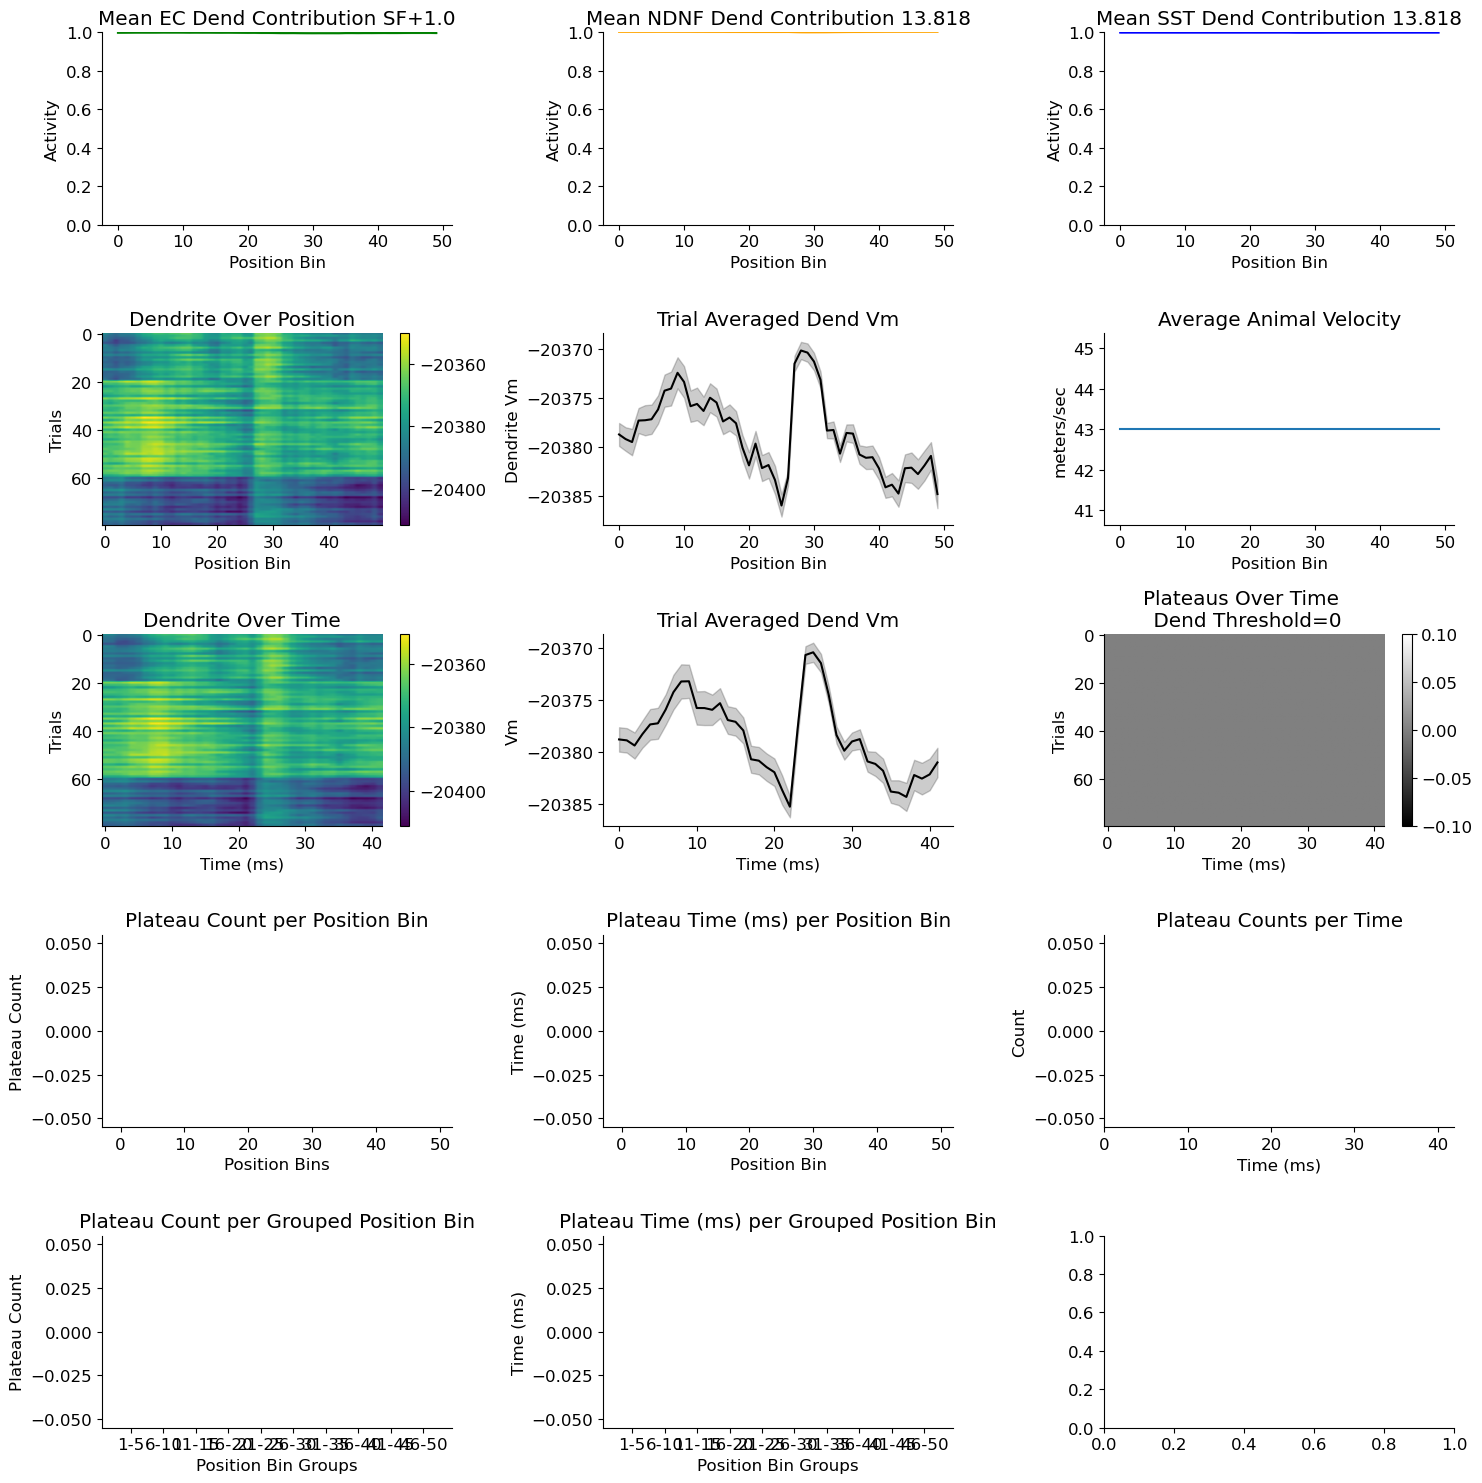

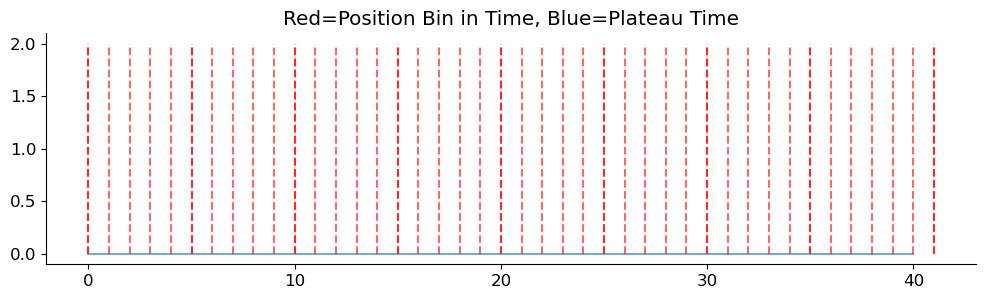

In [ ]:
mean_new_average_vel_array = get_real_velocity_array(filtered_factors_dict_EC, filtered_factors_dict_SST, fixed_filtered_factors_dict_NDNF_newest)
        
dendrite_contribution_EC, animal_velocity = get_dend_contr(residual_activity_dict_EC, full_activity_list_EC_trough, mean_new_average_vel_array, GLM_params_EC, vel=43, norm=False, add_vel_contribution=False, const_vel=True, raw_data_return_constant_vel=False)
dendrite_contribution_SST, animal_velocity = get_dend_contr(residual_activity_dict_SST, full_activity_list_SST_trough, mean_new_average_vel_array, GLM_params_SST, vel=43, norm=False, add_vel_contribution=False, const_vel=True, raw_data_return_constant_vel=False)
dendrite_contribution_NDNF, animal_velocity = get_dend_contr(fixed_residual_activity_dict_NDNF_newest, full_activity_list_NDNF_peak, mean_new_average_vel_array, GLM_params_NDNF_newest, vel=43, norm=False, add_vel_contribution=False, const_vel=True, raw_data_return_constant_vel=False)

summed_dendrite, an_velocity, padded_warped_activity, plateau_positions_counter, plateau_start_positions_counter, plateau_array, mean_dend_time, plateau_start_times_list, time_each_pos_bin_starts, x_time_ms, time_each_pos_bin_starts = get_dend_plateaus(dendrite_contribution_EC, dendrite_contribution_SST, dendrite_contribution_NDNF, animal_velocity, vel_applied=None, dend_threshold=0, inc_inh=True, remove_NDNF=True)
plot_single_dend(dendrite_contribution_EC, dendrite_contribution_SST, dendrite_contribution_NDNF, summed_dendrite, an_velocity, padded_warped_activity, plateau_positions_counter, plateau_start_positions_counter, plateau_array, mean_dend_time, x_time_ms, plateau_start_times_list, time_each_pos_bin_starts, NDNF_sf_opt, SST_sf_opt, include_inhibition=True)


In [ ]:
from scipy.optimize import minimize
import random
# Optimal NDNF_sf: 3.9426020962469455
# Optimal SST_sf: 3.942602096880944


def random_timeseries(initial_value: float, volatility: float, count: int) -> list:
    time_series = [initial_value, ]
    for _ in range(count):
        time_series.append(time_series[-1] + initial_value * random.gauss(0, 1) * volatility)
    return time_series

def get_dend_contribution_single_dend(residual_activity_dict_EC, activity_dict_EC, fixed_residual_activity_dict_NDNF_new, fixed_activity_dict_NDNF, residual_activity_dict_SST, activity_dict_SST, mean_new_average_vel_array, GLM_params_EC, vel_applied="constant"):

    if vel_applied=="real":

        if use_residuals:
            dend_contribution_EC, an_velocity, dend_list = get_dend_VM_cell_type(residual_activity_dict_EC, mean_new_average_vel_array, GLM_params_EC, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=True, const_vel=False)
            dend_contribution_NDNF, an_velocity, dend_list = get_dend_VM_cell_type(fixed_residual_activity_dict_NDNF_new, mean_new_average_vel_array, GLM_params, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=True, const_vel=False)
            dend_contribution_SST, an_velocity, dend_list = get_dend_VM_cell_type(residual_activity_dict_SST, mean_new_average_vel_array, GLM_params_SST, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=True, const_vel=False)

            EC = dend_contribution_EC.copy()
            NDNF = dend_contribution_NDNF.copy()
            SST = dend_contribution_SST.copy()

            result = minimize(loss_fn, x0=[1.0, 1.0], bounds=[(0, 5), (0, 5)])
            NDNF_sf_opt, SST_sf_opt = result.x
            print("Optimal NDNF_sf:", NDNF_sf_opt)
            print("Optimal SST_sf:", SST_sf_opt)

        else:
            dend_contribution_EC, an_velocity, dend_list = get_dend_VM_cell_type(activity_dict_EC, mean_new_average_vel_array, GLM_params_EC, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=True, const_vel=False)
            dend_contribution_NDNF, an_velocity, dend_list = get_dend_VM_cell_type(fixed_activity_dict_NDNF, mean_new_average_vel_array, GLM_params, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=True, const_vel=False)
            dend_contribution_SST, an_velocity, dend_list = get_dend_VM_cell_type(activity_dict_SST, mean_new_average_vel_array, GLM_params_SST, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=True, const_vel=False)

            EC = dend_contribution_EC.copy()
            NDNF = dend_contribution_NDNF.copy()
            SST = dend_contribution_SST.copy()

            result = minimize(loss_fn, x0=[1.0, 1.0], bounds=[(0, 5), (0, 5)])
            NDNF_sf_opt, SST_sf_opt = result.x
            print("Optimal NDNF_sf:", NDNF_sf_opt)
            print("Optimal SST_sf:", SST_sf_opt)

    elif vel_applied=="constant":
        if use_residuals:
            dend_contribution_EC, an_velocity, dend_list = get_dend_VM_cell_type(residual_activity_dict_EC, mean_new_average_vel_array, GLM_params_EC, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=False, const_vel=True)
            dend_contribution_NDNF, an_velocity, dend_list = get_dend_VM_cell_type(fixed_residual_activity_dict_NDNF_new, mean_new_average_vel_array, GLM_params, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=False, const_vel=True)
            dend_contribution_SST, an_velocity, dend_list = get_dend_VM_cell_type(residual_activity_dict_SST, mean_new_average_vel_array, GLM_params_SST, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=False, const_vel=True)

            EC = dend_contribution_EC.copy()
            NDNF = dend_contribution_NDNF.copy()
            SST = dend_contribution_SST.copy()

            result = minimize(loss_fn, x0=[1.0, 1.0], bounds=[(0, 5), (0, 5)])
            NDNF_sf_opt, SST_sf_opt = result.x
            print("Optimal NDNF_sf:", NDNF_sf_opt)
            print("Optimal SST_sf:", SST_sf_opt)

        else:
            dend_contribution_EC, an_velocity, dend_list = get_dend_VM_cell_type(activity_dict_EC, mean_new_average_vel_array, GLM_params_EC, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=False, const_vel=True)
            dend_contribution_NDNF, an_velocity, dend_list = get_dend_VM_cell_type(fixed_activity_dict_NDNF, mean_new_average_vel_array, GLM_params, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=False, const_vel=True)
            dend_contribution_SST, an_velocity, dend_list = get_dend_VM_cell_type(activity_dict_SST, mean_new_average_vel_array, GLM_params_SST, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=False, const_vel=True)

            EC = dend_contribution_EC.copy()
            NDNF = dend_contribution_NDNF.copy()
            SST = dend_contribution_SST.copy()

            result = minimize(loss_fn, x0=[1.0, 1.0], bounds=[(0, 5), (0, 5)])
            NDNF_sf_opt, SST_sf_opt = result.x
            print("Optimal NDNF_sf:", NDNF_sf_opt)
            print("Optimal SST_sf:", SST_sf_opt)

    elif vel_applied=="nothing":

        if use_residuals:
            dend_contribution_EC, an_velocity, dend_list = get_dend_VM_cell_type(residual_activity_dict_EC, mean_new_average_vel_array, GLM_params_EC, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=False, const_vel=False)
            dend_contribution_NDNF, an_velocity, dend_list = get_dend_VM_cell_type(fixed_residual_activity_dict_NDNF_new, mean_new_average_vel_array, GLM_params, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=False, const_vel=False)
            dend_contribution_SST, an_velocity, dend_list = get_dend_VM_cell_type(residual_activity_dict_SST, mean_new_average_vel_array, GLM_params_SST, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=False, const_vel=False)

            EC = dend_contribution_EC.copy()
            NDNF = dend_contribution_NDNF.copy()
            SST = dend_contribution_SST.copy()

            result = minimize(loss_fn, x0=[1.0, 1.0], bounds=[(0, 5), (0, 5)])
            NDNF_sf_opt, SST_sf_opt = result.x
            print("Optimal NDNF_sf:", NDNF_sf_opt)
            print("Optimal SST_sf:", SST_sf_opt)

        else:
            dend_contribution_EC, an_velocity, dend_list = get_dend_VM_cell_type(activity_dict_EC, mean_new_average_vel_array, GLM_params_EC, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=False, const_vel=False)
            dend_contribution_NDNF, an_velocity, dend_list = get_dend_VM_cell_type(fixed_activity_dict_NDNF, mean_new_average_vel_array, GLM_params, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=False, const_vel=False)
            dend_contribution_SST, an_velocity, dend_list = get_dend_VM_cell_type(activity_dict_SST, mean_new_average_vel_array, GLM_params_SST, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=False, const_vel=False)

            EC = dend_contribution_EC.copy()
            NDNF = dend_contribution_NDNF.copy()
            SST = dend_contribution_SST.copy()

            result = minimize(loss_fn, x0=[1.0, 1.0], bounds=[(0, 5), (0, 5)])
            NDNF_sf_opt, SST_sf_opt = result.x
            print("Optimal NDNF_sf:", NDNF_sf_opt)
            print("Optimal SST_sf:", SST_sf_opt)
            
    return dend_contribution_EC, dend_contribution_NDNF, dend_contribution_SST, an_velocity, NDNF_sf_opt, SST_sf_opt
        

def setup_single_dendrite(dend_contribution_EC, dend_contribution_NDNF, dend_contribution_SST, an_velocity, NDNF_sf_opt, SST_sf_opt, use_model_EC=False, include_inhibition=False, use_residuals=False, dend_threshold=0.75):
        
    if use_model_EC:
     

        ts_list = []
        for i in range(58):
            ts = random_timeseries(1.0, 0.005, 49)
            ts_list.append(ts)

        dend_contribution_EC = np.array(ts_list).T
        print(dend_contribution_EC.shape)
        

#         pos_bins = 50
#         trials = 58
#         dend_contribution_EC = np.zeros((pos_bins, trials))

#         # Fixed Gaussian centers
#         base_centers = np.arange(2, pos_bins, 5)  # bin 2, 7, 12, ..., 47
#         width = 2.0

#         for i in range(trials):
#             for center in base_centers:
#                 # Add jitter to the center (±1 bin)
#                 jittered_center = center + np.random.choice([-1, 0, 1])

#                 # Make sure jittered center stays within bounds
#                 jittered_center = np.clip(jittered_center, 0, pos_bins - 1)

#                 amplitude = np.random.uniform(0.8, 1.2)  # still jitter amplitude too
#                 gaussian = norm.pdf(np.arange(pos_bins), loc=jittered_center, scale=width)
#                 gaussian /= np.max(gaussian)
#                 dend_contribution_EC[:, i] += amplitude * gaussian

#         # Normalize globally if needed
#         dend_contribution_EC /= np.max(dend_contribution_EC)


    # NDNF_sf_opt = 3.7960282919084
    # SST_sf_opt = 4.108490240597229

    if include_inhibition:
        summed_dendrite = dend_contribution_EC - (dend_contribution_NDNF*NDNF_sf_opt + dend_contribution_SST*SST_sf_opt)
    #     summed_dendrite = dend_contribution_EC - (SST_sf_opt * dend_contribution_SST*2)

    else:
        summed_dendrite = dend_contribution_EC



#     animal_velocity_constant = np.full((summed_dendrite.shape), 23)
    total_time_sec = 4.71657036 

    dt=total_time_sec/50
    dx=180/50

#     animal_velocity_constant= np.full((summed_dendrite.shape), dx/dt)

    print(np.mean(an_velocity))



    dt_constant = 0.001
    # dt = dx / animal_velocity_constant
    dt = dx / (an_velocity*100)

    # if vel_applied == "nothing":
    #     dt = dx / animal_velocity_constant
    time_bins = np.cumsum(dt, axis=0)
    time_bins_ms = time_bins * 1

    num_trials = summed_dendrite.shape[1]
    trial_warped_activity = []
    max_len = 0

    for t in range(num_trials):
        if np.any(np.isnan(time_bins[:, t])):
            continue
        total_time = time_bins[-1, t]

        time_axis_constant = np.arange(0, total_time, dt_constant)

        firing = summed_dendrite[:, t]
        
        warped_firing = np.interp(time_axis_constant, time_bins_ms[:,t], firing)

        trial_warped_activity.append(warped_firing)
        if len(warped_firing) > max_len:
            max_len = len(warped_firing)

    padded_warped_activity = np.full((num_trials, max_len), np.nan) 
    for i, trace in enumerate(trial_warped_activity):
        padded_warped_activity[i, :len(trace)] = trace

    time_bin_size_ms = 1

    num_bins = len(mean_dend_time)
    x_time_ms = np.arange(num_bins) * time_bin_size_ms  # x-axis in ms


    position_bins, num_trials = an_velocity.shape


    flat_padded_warped_activity = padded_warped_activity.flatten()
    flat_plateau_array = np.zeros_like(flat_padded_warped_activity)

    i = 0
    while i < len(flat_padded_warped_activity):
        if flat_padded_warped_activity[i] > dend_threshold:
            flat_plateau_array[i:i+300] = 1

            i += 800
        else:
            i += 100


    plateau_array = flat_plateau_array.reshape(padded_warped_activity.shape)

    num_time_bins = padded_warped_activity.shape[1]

    plateau_positions_counter = np.zeros(50)

    time_in_bin_counter = np.zeros(50)

    animal_velocity = an_velocity * 100

    if vel_applied=="nothing":
        animal_velocity= mean_new_average_vel_array[:, None] * np.ones((1, summed_dendrite.shape[1])) *100

    

    plateau_start_positions_counter = np.zeros(50)  
    
    plateau_start_times_list = []

    for trial in range(plateau_array.shape[0]):
        velocity_trial = animal_velocity[:, trial]
        #         velocity_trial = proper_velocity
        dt_trial = dx / velocity_trial  # in seconds
        time_each_pos_bin_starts = np.concatenate([[0], np.cumsum(dt_trial)])

        plateau_start_indices = np.where(np.diff(np.pad(plateau_array[trial], (1, 0))) == 1)[0]
        plateau_start_times = plateau_start_indices * dt_constant  # in seconds
        plateau_start_times_list.append(plateau_start_times)

        for pt_start_time in plateau_start_times:
            if pt_start_time != 0.0:
                for pos_idx in range(50):
                    if time_each_pos_bin_starts[pos_idx] <= pt_start_time < time_each_pos_bin_starts[pos_idx + 1]:
                        plateau_start_positions_counter[pos_idx] += 1
                        break


    

    for trial in range(plateau_array.shape[0]):

        velocity_trial = animal_velocity[:, trial]  


        dt_trial = dx / velocity_trial  # in seconds

    #     print(f"np.cumsum(dt_trial) {np.cumsum(dt_trial)}")

        time_each_pos_bin_starts = np.concatenate([[0], np.cumsum(dt_trial)])

        time_binss = np.arange(num_time_bins) * dt_constant  

        for t_idx, time_bin in enumerate(time_binss):
            if plateau_array[trial, t_idx] == 1:
                for pos_idx in range(50):
                    if time_each_pos_bin_starts[pos_idx] <= time_bin < time_each_pos_bin_starts[pos_idx + 1]:
                        plateau_positions_counter[pos_idx] += 1
                        break


        for t_idx, time_bin in enumerate(time_binss):
            for pos_idx in range(50):
                if time_each_pos_bin_starts[pos_idx] <= time_bin < time_each_pos_bin_starts[pos_idx + 1]:
                    time_in_bin_counter[pos_idx] += 1
                    break



    return summed_dendrite, an_velocity, padded_warped_activity, plateau_positions_counter, plateau_start_positions_counter, plateau_array, mean_dend_time, plateau_start_times_list, time_each_pos_bin_starts, x_time_ms



def plot_single_dend(dend_contribution_EC, dend_contribution_SST, dend_contribution_NDNF, summed_dendrite, an_velocity, padded_warped_activity, plateau_positions_counter, plateau_start_positions_counter, plateau_array, mean_dend_time, x_time_ms, plateau_start_times_list):

    fig, axs = plt.subplots(5, 3, figsize=(15, 15))  
#     plt.suptitle(f"include_inhibition={include_inhibition}, use_model_EC={use_model_EC}, use_residuals={use_residuals}, velocity modulation={vel_applied}")


    EC_normalized = dend_contribution_EC/ np.max(dend_contribution_EC)

    mean_EC_dend = np.mean(EC_normalized, axis=1)
    sem_EC_dend = sem(EC_normalized, axis=1)
    axs[0,0].plot(mean_EC_dend, color='g', label="EC Vel")
    axs[0,0].fill_between(range(len(mean_EC_dend)), mean_EC_dend+sem_EC_dend, mean_EC_dend-sem_EC_dend, alpha=0.2, color='g')
    axs[0,0].set_title(f"Mean EC Dend Contribution SF+{1.0}")
    axs[0,0].set_xlabel("Position Bin")
    axs[0,0].set_ylabel("Activity")
    axs[0,0].set_ylim(0,1)

    if include_inhibition:

        SST_normalized = dend_contribution_SST/ np.max(dend_contribution_SST)

        mean_SST_dend = np.mean(SST_normalized, axis=1)
        sem_SST_dend = sem(SST_normalized, axis=1)
        axs[0,2].plot(mean_SST_dend, color='b', label="SST Vel")
        axs[0,2].fill_between(range(len(mean_SST_dend)), mean_SST_dend+sem_SST_dend, mean_SST_dend-sem_SST_dend, alpha=0.2, color='b')
        axs[0,2].set_title(f"Mean SST Dend Contribution {SST_sf_opt:.3f}")
        axs[0,2].set_xlabel("Position Bin")
        axs[0,2].set_ylabel("Activity")
        axs[0,2].set_ylim(0,1)

        NDNF_normalized = dend_contribution_NDNF/ np.max(dend_contribution_NDNF)

        mean_NDNF_dend = np.mean(NDNF_normalized, axis=1)
        sem_NDNF_dend = sem(NDNF_normalized, axis=1)
        axs[0,1].plot(mean_NDNF_dend, color='orange', label="NDNF Vel")
    #     axs[0,1].plot(np.zeros(50), color='orange', label="NDNF Vel")
        axs[0,1].fill_between(range(len(mean_NDNF_dend)), mean_NDNF_dend+sem_NDNF_dend, mean_NDNF_dend-sem_NDNF_dend, alpha=0.2, color='orange')
        axs[0,1].set_title(f"Mean NDNF Dend Contribution {NDNF_sf_opt:.3f}")
        axs[0,1].set_xlabel("Position Bin")
        axs[0,1].set_ylabel("Activity")
        axs[0,1].set_ylim(0,1)   



    im11 = axs[1,0].imshow(summed_dendrite.T, aspect='auto')
    axs[1,0].set_title("Dendrite Over Position")
    axs[1,0].set_xlabel("Position Bin")
    axs[1,0].set_ylabel("Trials")
    fig.colorbar(im11, ax=axs[1,0])

    if include_inhibition: 
        axs[1,2].plot(an_velocity[:,0])
        axs[1,2].set_title("Average Animal Velocity")
        axs[1,2].set_ylabel("meters/sec")
        axs[1,2].set_xlabel("Position Bin")

    else:
        axs[0,1].plot(an_velocity[:,0])
        axs[0,1].set_title("Average Animal Velocity")
        axs[0,1].set_ylabel("meters/sec")
        axs[0,1].set_xlabel("Position Bin")




    mean_dendrite = np.mean(summed_dendrite, axis=1)
    sem_dendrite = sem(summed_dendrite, axis=1)

    axs[1,1].plot(mean_dendrite, color='k')
    axs[1,1].fill_between(range(len(mean_dendrite)), mean_dendrite+sem_dendrite, mean_dendrite-sem_dendrite, alpha=0.2, color='k')
    axs[1,1].set_title("Trial Averaged Dend Vm")
    axs[1,1].set_xlabel("Position Bin")
    axs[1,1].set_ylabel("Dendrite Vm")


    x_start = 0
    time_bin_size_ms=1
    num_bins = len(mean_dend_time)
    x_end = num_bins * time_bin_size_ms 
    im = axs[2,0].imshow(padded_warped_activity, aspect='auto')
    axs[2,0].set_title("Dendrite Over Time")
    axs[2,0].set_xlabel("Time (ms)")
    axs[2,0].set_ylabel("Trials")
    fig.colorbar(im, ax=axs[2,0])
    
    
    mean_dend_time = np.mean(padded_warped_activity, axis=0)
    sem_dend_time = sem(padded_warped_activity, axis=0)

    axs[2,1].plot(x_time_ms, mean_dend_time, color='k')
    axs[2,1].fill_between(x_time_ms, mean_dend_time+sem_dend_time, mean_dend_time-sem_dend_time, color='k', alpha=0.2)
    axs[2,1].set_title("Trial Averaged Dend Vm")
    axs[2,1].set_xlabel("Time (ms)")
    axs[2,1].set_ylabel("Vm")

    im2 = axs[2,2].imshow(plateau_array, aspect='auto', interpolation=None, cmap="gray")
    axs[2,2].set_title(f"Plateaus Over Time \n Dend Threshold={dend_threshold}")
    axs[2,2].set_xlabel("Time (ms)")
    axs[2,2].set_ylabel("Trials")
    fig.colorbar(im2, ax=axs[2,2])


    sum_plateaus = np.nansum(plateau_array, axis=0)
    axs[3,2].bar(range(len(sum_plateaus)),sum_plateaus)
    axs[3,2].set_xlim(0, plateau_array.shape[1])  # full time range
    axs[3,2].set_xlabel("Time (ms)")
    axs[3,2].set_ylabel("Count")
    axs[3,2].set_title("Plateau Counts per Time")

    axs[3,0].bar(range(len(plateau_start_positions_counter)), plateau_start_positions_counter)
    axs[3,0].set_xlabel("Position Bins")
    axs[3,0].set_ylabel("Plateau Count")
    axs[3,0].set_title("Plateau Count per Position Bin")

    bin_size = 5
    grouped_counts = [np.sum(plateau_start_positions_counter[i:i+bin_size]) for i in range(0, len(plateau_start_positions_counter), bin_size)]

    axs[4,0].bar(range(len(grouped_counts)), grouped_counts)
    axs[4,0].set_xticks(np.arange(10), ["1-5", "6-10", "11-15", "16-20", "21-25", "26-30", "31-35", "36-40", "41-45", "46-50"])
    axs[4,0].set_xlabel(f"Position Bin Groups")
    axs[4,0].set_ylabel("Plateau Count")
    axs[4,0].set_title("Plateau Count per Grouped Position Bin")


    axs[3,1].bar(range(len(plateau_positions_counter)), plateau_positions_counter)
    axs[3,1].set_title("Plateau Time (ms) per Position Bin")
    axs[3,1].set_ylabel("Time (ms)")
    axs[3,1].set_xlabel("Position Bin")

    bin_size = 5
    grouped_counts = [np.sum(plateau_positions_counter[i:i+bin_size]) for i in range(0, len(plateau_positions_counter), bin_size)]

    axs[4,1].bar(range(len(grouped_counts)), grouped_counts)
    axs[4,1].set_xticks(np.arange(10), ["1-5", "6-10", "11-15", "16-20", "21-25", "26-30", "31-35", "36-40", "41-45", "46-50"])
    axs[4,1].set_xlabel(f"Position Bin Groups")
    axs[4,1].set_ylabel("Time (ms)")
    axs[4,1].set_title("Plateau Time (ms) per Grouped Position Bin")


    plt.tight_layout()
    plt.show()
    
    final_bin = time_each_position_bin_starts[-1] *1000
    timecourse = np.zeros(int(final_bin))
    timecourse_bins = np.zeros(int(final_bin))

    plateau_start_times_list_cleaned = []
    for trial in range(len(plateau_start_times_list)):
        if np.any(plateau_start_times_list[trial]!=0):
            for i in plateau_start_times_list[trial]:
                plateau_start_times_list_cleaned.append(int(i*1000))


    for plateau in plateau_start_times_list_cleaned:
        timecourse[plateau] = 1

    # for bins in time_each_position_bin_starts:
    #     if bins < time_each_position_bin_starts[-1]:
    #         bins_scaled = int(bins*1000)
    #         timecourse_bins[bins_scaled] = 2

    plt.figure(figsize=(12,3))

    # Plot dashed vertical red lines at bin starts
    for bins in time_each_position_bin_starts:
        bins_scaled = int(bins * 1000)
        plt.vlines(bins_scaled, ymin=0, ymax=2, color='r', linestyle='--', alpha=0.6)
    plt.plot(timecourse, alpha=0.6)
    plt.title("Red=Position Bin in Time, Blue=Plateau Time")
    plt.show()


    
# trial_unwarped_activity = [] 
    
# for t in range(num_trials):
#     if np.any(np.isnan(time_bins[:, t])):
#         continue
#     total_time = time_bins[-1, t]

#     time_axis_constant = np.arange(0, total_time, dt_constant)
    
#     warped_firing = padded_warped_activity[t,:]

#     unwarped_firing = np.interp(time_bins_ms[:,t], time_axis_constant, warped_firing)

#     trial_unwarped_activity.append(unwarped_firing)
#     if len(unwarped_firing) > max_len:
#         max_len = len(unwarped_firing)
            
# padded_unwarped_activity = np.full((num_trials, max_len), np.nan) 
# for i, trace in enumerate(trial_unwarped_activity):
#     padded_unwarped_activity[i, :len(trace)] = trace

    
            

# mean_dend_time = np.mean(padded_unwarped_activity, axis=0)
# sem_dend_time = sem(padded_unwarped_activity, axis=0)
# plt.plot(mean_dend_time)
# plt.fill_between(range(len(mean_dend_time)), mean_dend_time+sem_dend_time, mean_dend_time-sem_dend_time, alpha=0.2)
# plt.show()